## **INTRODUCTION**



Loan default prediction is a critical challenge in the banking and financial sector because customers who fail to repay their loans can lead to significant financial losses for lending institutions. Accurately identifying customers who are likely to default enables banks to make informed lending decisions, reduce credit risk, improve profitability, and maintain a healthy loan portfolio.

With the increasing availability of customer financial data, machine learning techniques have become valuable tools for predicting loan default by identifying complex patterns in customer demographics, credit history, repayment behaviour, and financial records. These predictive models support financial institutions in assessing creditworthiness and making more reliable lending decisions.

This project uses the **Default of Credit Card Clients** dataset to develop and evaluate machine learning models capable of predicting whether a customer is likely to default on a loan. The project follows a complete data science workflow, including data cleaning, exploratory data analysis (EDA), data preprocessing, model development, hyperparameter tuning, and performance evaluation using multiple classification metrics.

**Project Objectives**

The objectives of this project are to:

- Develop machine learning models to predict customer loan default.
- Perform exploratory data analysis to understand customer financial behaviour and identify important patterns in the data.
- Compare the performance of multiple classification algorithms using appropriate evaluation metrics.
- Identify the best-performing model for loan default prediction.
- Demonstrate how machine learning can support credit risk assessment and improve lending decisions in financial institutions.


**PAYMENT STATUS CODE**

| Value | Meaning |
|--------|-------------------------------|
| -2 | No consumption |
| -1 | Paid in full |
| 0 | Payment made on time |
| 1 | One month payment delay |
| 2 | Two months payment delay |
| 3 | Three months payment delay |
| 4 | Four months payment delay |
| 5 | Five months payment delay |
| 6 | Six months payment delay |
| 7 | Seven months payment delay |
| 8 | Eight months payment delay |

**Project Workflow**

Title

Introduction

Project Objectives

Project Workflow

Import Libraries

Load Dataset

Data Cleaning

Exploratory Data Analysis/Visualization

Model Development
    • Logistic Regression
    • Random Forest
    • XGBoost
    • KNN
    • SVM

Model Comparison

Modelling Summary

Key Insights

Project Limitations

Recommendations

Conclusion

# **STEP 1:** IMPORTING THE NECCESSARY LIBRARIES AND CLEANING THE DATASET
The first step is importing the libraries required for data manipulation,
visualization and building models.

- Pandas: Data manipulation
- NumPy: Numerical computations
- Matplotlib & Seaborn: Data visualization
- Warnings: Ignore unnecessary warnings
- Scikit-learn :For features engineering, handling imbalance dataset and  modelling

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings

import warnings
warnings.filterwarnings('ignore')

# Display all columns

pd.set_option('display.max_columns', None)

# Display decimal places

pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

# Model selection

from sklearn.model_selection import train_test_split

# Feature Scaling

from sklearn.preprocessing import StandardScaler

# Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost
from xgboost import XGBClassifier

# Model Evaluation

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
confusion_matrix,classification_report,roc_curve,roc_auc_score)

#Handling imbalanced dataset

from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline



# **DATASET LOADING**
First, the file containing the dataset was converted to a CSV format.The dataset is imported into a Pandas DataFrame. The second row of the csv
file contains the actual column names, therefore `header=1` is used.

In [2]:
# Load the dataset

df = pd.read_csv(r"C:\Users\HP\Desktop\python\DATASETS\CAPSTONE\default of credit card clients2.csv", header=1)

# Display first five rows 

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **SAVING THE ORIGINAL DATASET TO A NEW VARIABLE** 

We keep the original (raw) dataset so we always have an untouched backup to return to if any mistakes are made during data cleaning or analysis.

In [3]:
raw_df = df.copy()

raw_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


# **DATA CLEANING/PREPROCESSING**

## **DATASET OVERVIEW**

Understanding the dimensions of the dataset helps determine the number of
observations and variables available for analysis.

In [4]:
# Shape of the dataset
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 30000
Columns: 25


In [5]:
# Display first five records
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
# Display last five records
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [7]:
# Random sample
df.sample(5, random_state=2)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
7945,7946,20000,2,2,1,37,0,0,2,0,0,0,17450,20358,19722,19616,19228,19878,3200,0,830,750,1000,282,1
16536,16537,500000,1,2,2,26,0,0,0,0,0,0,126725,128206,129327,130136,127699,124623,6005,6005,6094,4161,5021,4350,0
26726,26727,150000,1,1,2,26,-2,-1,0,0,-1,-1,600,360,1401,2360,70,420,360,1041,1000,70,660,0,0
16333,16334,60000,2,2,1,36,0,0,0,0,0,0,60299,44659,44291,41241,29534,29297,2000,3042,1433,1012,1029,1074,1
20629,20630,220000,1,1,2,29,0,0,0,0,0,0,26012,25916,24998,23965,23865,23667,1410,1417,1333,731,1019,1045,0


## **INSPECTING COLUMN NAMES**

In [8]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

## **RENAMING THE COLUMNS**
Some column names in the original dataset are abbreviated and difficult to interpret. Renaming them improves readability and makes subsequent analysis easier to understand without changing the underlying data.
The target column is renamed to `DEFAULT`.

In [9]:
df.rename(columns={
    "default payment next month":"DEFAULT",
    "PAY_0":"PAY_SEP",
    "PAY_2":"PAY_AUG",
    "PAY_3":"PAY_JUL",
    "PAY_4":"PAY_JUN",
    "PAY_5":"PAY_MAY",
    "PAY_6":"PAY_APR",
    "BILL_AMT1":"BILL_AMT_SEP",
    "BILL_AMT2":"BILL_AMT_AUG",
    "BILL_AMT3":"BILL_AMT_JUL",
    "BILL_AMT4":"BILL_AMT_JUN",
    "BILL_AMT5":"BILL_AMT_MAY",
    "BILL_AMT6":"BILL_AMT_APR",
    "PAY_AMT1":"PAY_AMT_SEP",
    "PAY_AMT2":"PAY_AMT_AUG",
    "PAY_AMT3":"PAY_AMT_JUL",
    "PAY_AMT4":"PAY_AMT_JUN",
    "PAY_AMT5":"PAY_AMT_MAY",
    "PAY_AMT6":"PAY_AMT_APR"
}, inplace=True)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **DATASET INFORMATION**
The `.info()` function provides an overview of the dataset, including the number of rows and columns, missing values, and the data type of each feature. It helps identify potential data quality issues before cleaning.

In [10]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ID            30000 non-null  int64
 1   LIMIT_BAL     30000 non-null  int64
 2   SEX           30000 non-null  int64
 3   EDUCATION     30000 non-null  int64
 4   MARRIAGE      30000 non-null  int64
 5   AGE           30000 non-null  int64
 6   PAY_SEP       30000 non-null  int64
 7   PAY_AUG       30000 non-null  int64
 8   PAY_JUL       30000 non-null  int64
 9   PAY_JUN       30000 non-null  int64
 10  PAY_MAY       30000 non-null  int64
 11  PAY_APR       30000 non-null  int64
 12  BILL_AMT_SEP  30000 non-null  int64
 13  BILL_AMT_AUG  30000 non-null  int64
 14  BILL_AMT_JUL  30000 non-null  int64
 15  BILL_AMT_JUN  30000 non-null  int64
 16  BILL_AMT_MAY  30000 non-null  int64
 17  BILL_AMT_APR  30000 non-null  int64
 18  PAY_AMT_SEP   30000 non-null  int64
 19  PAY_AMT_AUG   30000 non-n

## **STATISTICAL SUMMARY**

Summary statistics provide information about the distribution of numerical
variables including:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Quartiles

 It helps identify unusual values and understand the distribution of the data.

In [11]:
df.describe(). T  # T MEANS TRANSPOSE. IT MAKES THE OUTPUT EASIER TO READ

,count,mean,std,min,25%,50%,75%,max
ID,30000.00,15000.50,8660.40,1.00,7500.75,15000.50,22500.25,30000.00
LIMIT_BAL,30000.00,167484.32,129747.66,10000.00,50000.00,140000.00,240000.00,1000000.00
SEX,30000.00,1.60,0.49,1.00,1.00,2.00,2.00,2.00
EDUCATION,30000.00,1.85,0.79,0.00,1.00,2.00,2.00,6.00
MARRIAGE,30000.00,1.55,0.52,0.00,1.00,2.00,2.00,3.00
AGE,30000.00,35.49,9.22,21.00,28.00,34.00,41.00,79.00
PAY_SEP,30000.00,-0.02,1.12,-2.00,-1.00,0.00,0.00,8.00
PAY_AUG,30000.00,-0.13,1.20,-2.00,-1.00,0.00,0.00,8.00
PAY_JUL,30000.00,-0.17,1.20,-2.00,-1.00,0.00,0.00,8.00
PAY_JUN,30000.00,-0.22,1.17,-2.00,-1.00,0.00,0.00,8.00


## **MISSING VALUES ANALYSIS**

Missing values can affect statistical analysis and machine learning models. This step verifies whether any observations contain null values that require treatment.

In [12]:
df.isnull().sum()

ID              0
LIMIT_BAL       0
SEX             0
EDUCATION       0
MARRIAGE        0
AGE             0
PAY_SEP         0
PAY_AUG         0
PAY_JUL         0
PAY_JUN         0
PAY_MAY         0
PAY_APR         0
BILL_AMT_SEP    0
BILL_AMT_AUG    0
BILL_AMT_JUL    0
BILL_AMT_JUN    0
BILL_AMT_MAY    0
BILL_AMT_APR    0
PAY_AMT_SEP     0
PAY_AMT_AUG     0
PAY_AMT_JUL     0
PAY_AMT_JUN     0
PAY_AMT_MAY     0
PAY_AMT_APR     0
DEFAULT         0
dtype: int64

The dataset above contains no missing values; therefore, no imputation or deletion was required.

## **CHECKING FOR UNIQUE VALUES**
This helps identify invalid category codes such as:

EDUCATION = 0, 5, 6
MARRIAGE = 0


In [13]:
for col in ['SEX','EDUCATION','MARRIAGE','DEFAULT']:
    print(df[col].value_counts())
    print("-"*40)

SEX
2    18112
1    11888
Name: count, dtype: int64
----------------------------------------
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
----------------------------------------
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
----------------------------------------
DEFAULT
0    23364
1     6636
Name: count, dtype: int64
----------------------------------------


## **CORRECTING INVALID VALUES**
Why this step?

Although these records appear in the dataset, the original data description defines only:

- Education: 1 = Graduate School, 2 = University, 3 = High School, 4 = Others.

- Marriage: 1 = Married, 2 = Single, 3 = Others.

Recoding 0, 5, and 6 into the "Others" category prevents the model from treating them as separate, unsupported classes. This ensures that every category corresponds to a valid documented class.

In [14]:
# For EDUCATION, values 0, 5, and 6 represent "Others" (4).
df['EDUCATION'] = df['EDUCATION'].replace({
    0:4,
    5:4,
    6:4
})

 0, 5, and 6 was replace with 4 because 4 is the only documented category that can reasonably represent unknown or undocumented education levels. This preserves the data while ensuring every value belongs to a valid category defined by the dataset documentation.

In [15]:
# For MARRIAGE, value 0 is also grouped into "Others" (3).
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

The dataset documentation defines only 1 (Married), 2 (Single), and 3 (Others) as valid categories for the MARRIAGE variable. Since 0 is an undocumented category, it is replaced with 3 (Others) to ensure all records belong to valid and documented marital status categories without removing valuable data.

In [16]:
print(df['EDUCATION'].value_counts())
print(df['MARRIAGE'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


### **Verification of Repayment Status Variables**

According to the published documentation, repayment status values range from -1 to 9. However, inspection of the dataset revealed two additional categories: -2 and 0.

These values are retained because they represent legitimate repayment states in the original dataset rather than data errors.

- -2 : No consumption / no bill generated
- -1 : Paid duly
- 0 : Revolving credit or no payment delay
- 1–9 : One to nine or more months of payment delay

Therefore, no modifications were made to the repayment status variables.

## **REMOVING THE ID COLUMN**
The ID variable uniquely identifies each customer but carries no predictive
information. It is removed to avoid introducing noise into the machine
learning model.

In [17]:
df.drop(columns="ID", inplace=True)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **VERIFYING DATA TYPES**
This ensure:

Numeric variables are int64 or float64.
The target variable DEFAULT remains an integer (0 and 1) for classification.

In [18]:
df.dtypes

LIMIT_BAL       int64
SEX             int64
EDUCATION       int64
MARRIAGE        int64
AGE             int64
PAY_SEP         int64
PAY_AUG         int64
PAY_JUL         int64
PAY_JUN         int64
PAY_MAY         int64
PAY_APR         int64
BILL_AMT_SEP    int64
BILL_AMT_AUG    int64
BILL_AMT_JUL    int64
BILL_AMT_JUN    int64
BILL_AMT_MAY    int64
BILL_AMT_APR    int64
PAY_AMT_SEP     int64
PAY_AMT_AUG     int64
PAY_AMT_JUL     int64
PAY_AMT_JUN     int64
PAY_AMT_MAY     int64
PAY_AMT_APR     int64
DEFAULT         int64
dtype: object

## **FINAL CLEANING CHECK**

In [19]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (30000, 24)

Missing Values:
0

Duplicate Records:
35

Data Types:
LIMIT_BAL       int64
SEX             int64
EDUCATION       int64
MARRIAGE        int64
AGE             int64
PAY_SEP         int64
PAY_AUG         int64
PAY_JUL         int64
PAY_JUN         int64
PAY_MAY         int64
PAY_APR         int64
BILL_AMT_SEP    int64
BILL_AMT_AUG    int64
BILL_AMT_JUL    int64
BILL_AMT_JUN    int64
BILL_AMT_MAY    int64
BILL_AMT_APR    int64
PAY_AMT_SEP     int64
PAY_AMT_AUG     int64
PAY_AMT_JUL     int64
PAY_AMT_JUN     int64
PAY_AMT_MAY     int64
PAY_AMT_APR     int64
DEFAULT         int64
dtype: object


## **REMOVING DUPLICATED RECORDS**

Duplicate records can bias statistical analysis and machine learning models by giving repeated observations more influence than intended. Therefore, duplicate rows are identified and removed.

In [20]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify
print("Duplicate Records:", df.duplicated().sum())
print("Dataset Shape:", df.shape)

Duplicate Records: 0
Dataset Shape: (29965, 24)


## **EXPORTING THE CLEANED DATAFRAME TO CSV**

In [21]:
df.to_csv("cleaned_default_credit_card_client.csv", index=False)


## **DATA CLEANING SUMMARY**
These steps where taken in during the data cleaning phase

- Loaded the dataset and inspected its structure.
- Renamed the target variable and selected columns for readability.
- Checked for missing values (none found).
- Checked for duplicate records and removed them .
- Corrected invalid category codes in EDUCATION and MARRIAGE.
- Removed the ID column because it has no predictive value.
- Verified repayment status (PAY_0 to PAY_6) variables and retained -2 and 0 because they are legitimate categories in the dataset, despite not being fully described in the accompanying documentation.
- Confirmed that the dataset is clean, consistent, and ready for exploratory data analysis (EDA) and predictive model development.

# **STEP 2:** EXPLORATORY DATA ANALYSIS AND VISUALIZATION

### **Project Overview**
This project also performs an Exploratory Data Analysis (EDA) on the Credit Card Default dataset.

The objective is to understand the characteristics of the data, identify patterns among customers, explore relationships between variables, detect outliers, and generate insights that will support the development of an accurate machine learning model for predicting customer loan default.

Since the dataset has already been cleaned during the preprocessing stage, this notebook focuses entirely on exploration and visualization.

## **DATA OVERVIEW**

Before creating visualizations, it is important to understand the size and structure of the dataset.

This helps verify that the dataset loaded correctly and provides an overview of the available features.

In [22]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [23]:
df.shape

(29965, 24)

In [24]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEP',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_AMT_SEP',
       'BILL_AMT_AUG', 'BILL_AMT_JUL', 'BILL_AMT_JUN', 'BILL_AMT_MAY',
       'BILL_AMT_APR', 'PAY_AMT_SEP', 'PAY_AMT_AUG', 'PAY_AMT_JUL',
       'PAY_AMT_JUN', 'PAY_AMT_MAY', 'PAY_AMT_APR', 'DEFAULT'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   LIMIT_BAL     29965 non-null  int64
 1   SEX           29965 non-null  int64
 2   EDUCATION     29965 non-null  int64
 3   MARRIAGE      29965 non-null  int64
 4   AGE           29965 non-null  int64
 5   PAY_SEP       29965 non-null  int64
 6   PAY_AUG       29965 non-null  int64
 7   PAY_JUL       29965 non-null  int64
 8   PAY_JUN       29965 non-null  int64
 9   PAY_MAY       29965 non-null  int64
 10  PAY_APR       29965 non-null  int64
 11  BILL_AMT_SEP  29965 non-null  int64
 12  BILL_AMT_AUG  29965 non-null  int64
 13  BILL_AMT_JUL  29965 non-null  int64
 14  BILL_AMT_JUN  29965 non-null  int64
 15  BILL_AMT_MAY  29965 non-null  int64
 16  BILL_AMT_APR  29965 non-null  int64
 17  PAY_AMT_SEP   29965 non-null  int64
 18  PAY_AMT_AUG   29965 non-null  int64
 19  PAY_AMT_JUL   29965 non-null  

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.00,167442.01,129760.14,10000.00,50000.00,140000.00,240000.00,1000000.00
SEX,29965.00,1.60,0.49,1.00,1.00,2.00,2.00,2.00
EDUCATION,29965.00,1.84,0.74,1.00,1.00,2.00,2.00,4.00
MARRIAGE,29965.00,1.56,0.52,1.00,1.00,2.00,2.00,3.00
AGE,29965.00,35.49,9.22,21.00,28.00,34.00,41.00,79.00
PAY_SEP,29965.00,-0.02,1.12,-2.00,-1.00,0.00,0.00,8.00
PAY_AUG,29965.00,-0.13,1.20,-2.00,-1.00,0.00,0.00,8.00
PAY_JUL,29965.00,-0.16,1.20,-2.00,-1.00,0.00,0.00,8.00
PAY_JUN,29965.00,-0.22,1.17,-2.00,-1.00,0.00,0.00,8.00
PAY_MAY,29965.00,-0.26,1.13,-2.00,-1.00,0.00,0.00,8.00


## **DISTRIBUTION OF LOAN DEFAULT**

Understanding the distribution of the target variable is one of the most important steps in EDA.

This reveals whether the dataset is balanced or imbalanced, which can significantly affect the performance of machine learning models.

In [27]:
Default_counts = df["DEFAULT"].value_counts().reset_index()
Default_counts["percentage"] = (Default_counts["count"]/Default_counts["count"].sum())*100
Default_counts

,DEFAULT,count,percentage
0,0,23335,77.87
1,1,6630,22.13


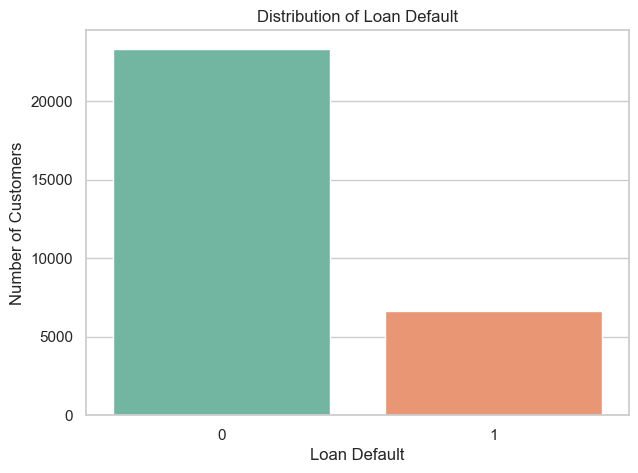

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(data=Default_counts,
              x='DEFAULT',
              y= 'count',
              palette='Set2')

plt.title("Distribution of Loan Default")
plt.xlabel("Loan Default")
plt.ylabel("Number of Customers")

plt.show()

From the above distribution;

- Majority of customers (77.87%) did not default.
- The dataset appears imbalanced as only 22.13% defaulted compared to 77.13% that did not default.
- Class imbalance should be considered during model building.

## **DISTRIBUTION OF NUMERICAL VARIABLES**

Histograms will be used here to help us understand the shape, spread, skewness and presence of extreme values(outliers) in numerical features.

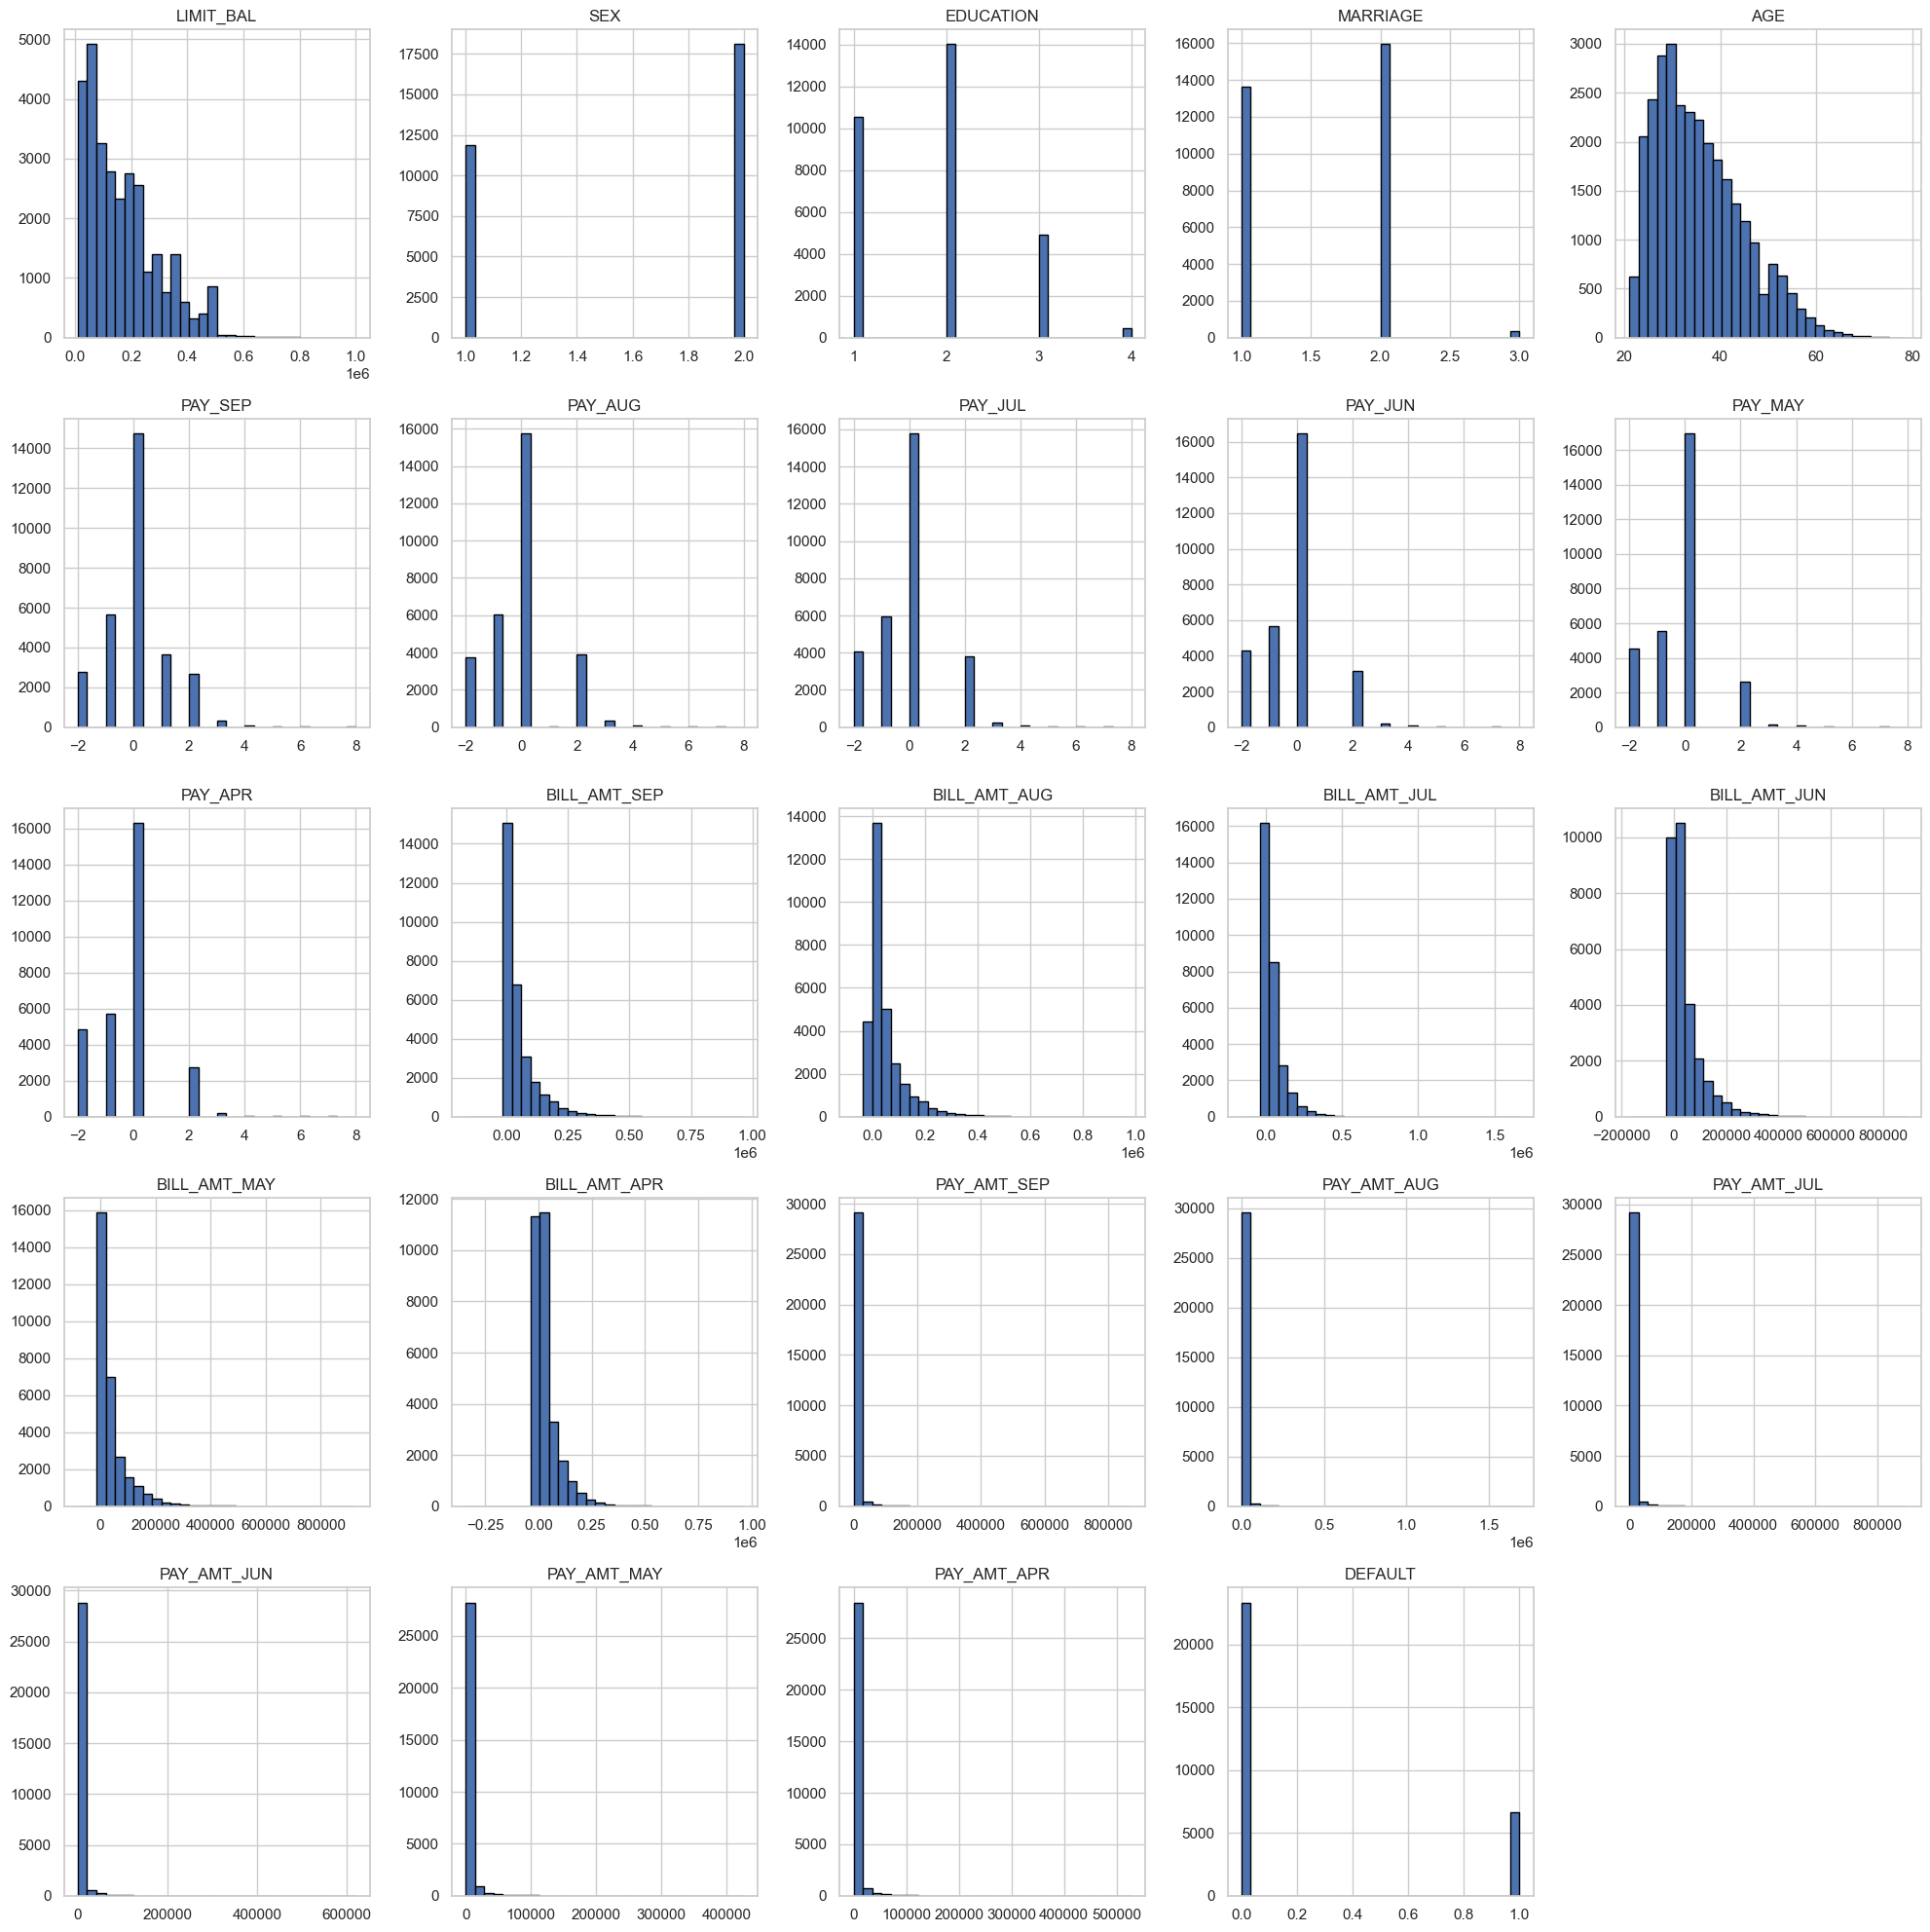

In [29]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(20,20),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()


 **Key Observations**

- Several variables exhibit **right-skewed distributions**, where a large proportion of observations are concentrated at lower values with a long tail extending toward higher values. This pattern is common in financial datasets because a small number of customers typically have significantly higher credit limits, bill amounts, or payment amounts than the majority.

- Variables such as **LIMIT_BAL**, **BILL_AMT_APR–BILL_AMT_SEP**, and **PAY_AMT_APR–PAY_AMT_SEP** show wide ranges, indicating substantial variation in customers' financial behaviour.

- The **AGE** variable appears more evenly distributed, with most customers falling within the middle-age range, while relatively few customers belong to the youngest or oldest age groups.

- Payment status variables (**PAY_APR to PAY_SEP**) display discrete distributions because they represent repayment status categories rather than continuous numerical values.

- Also the payment status distributions shows that most of the customers paid duly each month.

- The presence of long tails in several financial variables suggests the existence of customers with exceptionally high balances or payments.

 **Insight**

The observed distributions indicate that customer financial behaviour varies considerably across the dataset. 

## **DETECTING OUTLIERS**

Outliers are extreme observations that differ significantly from the rest of the data.

Although outliers are not always removed, they should be identified because they may influence statistical analysis and machine learning models. Box plot will be use to handle that.

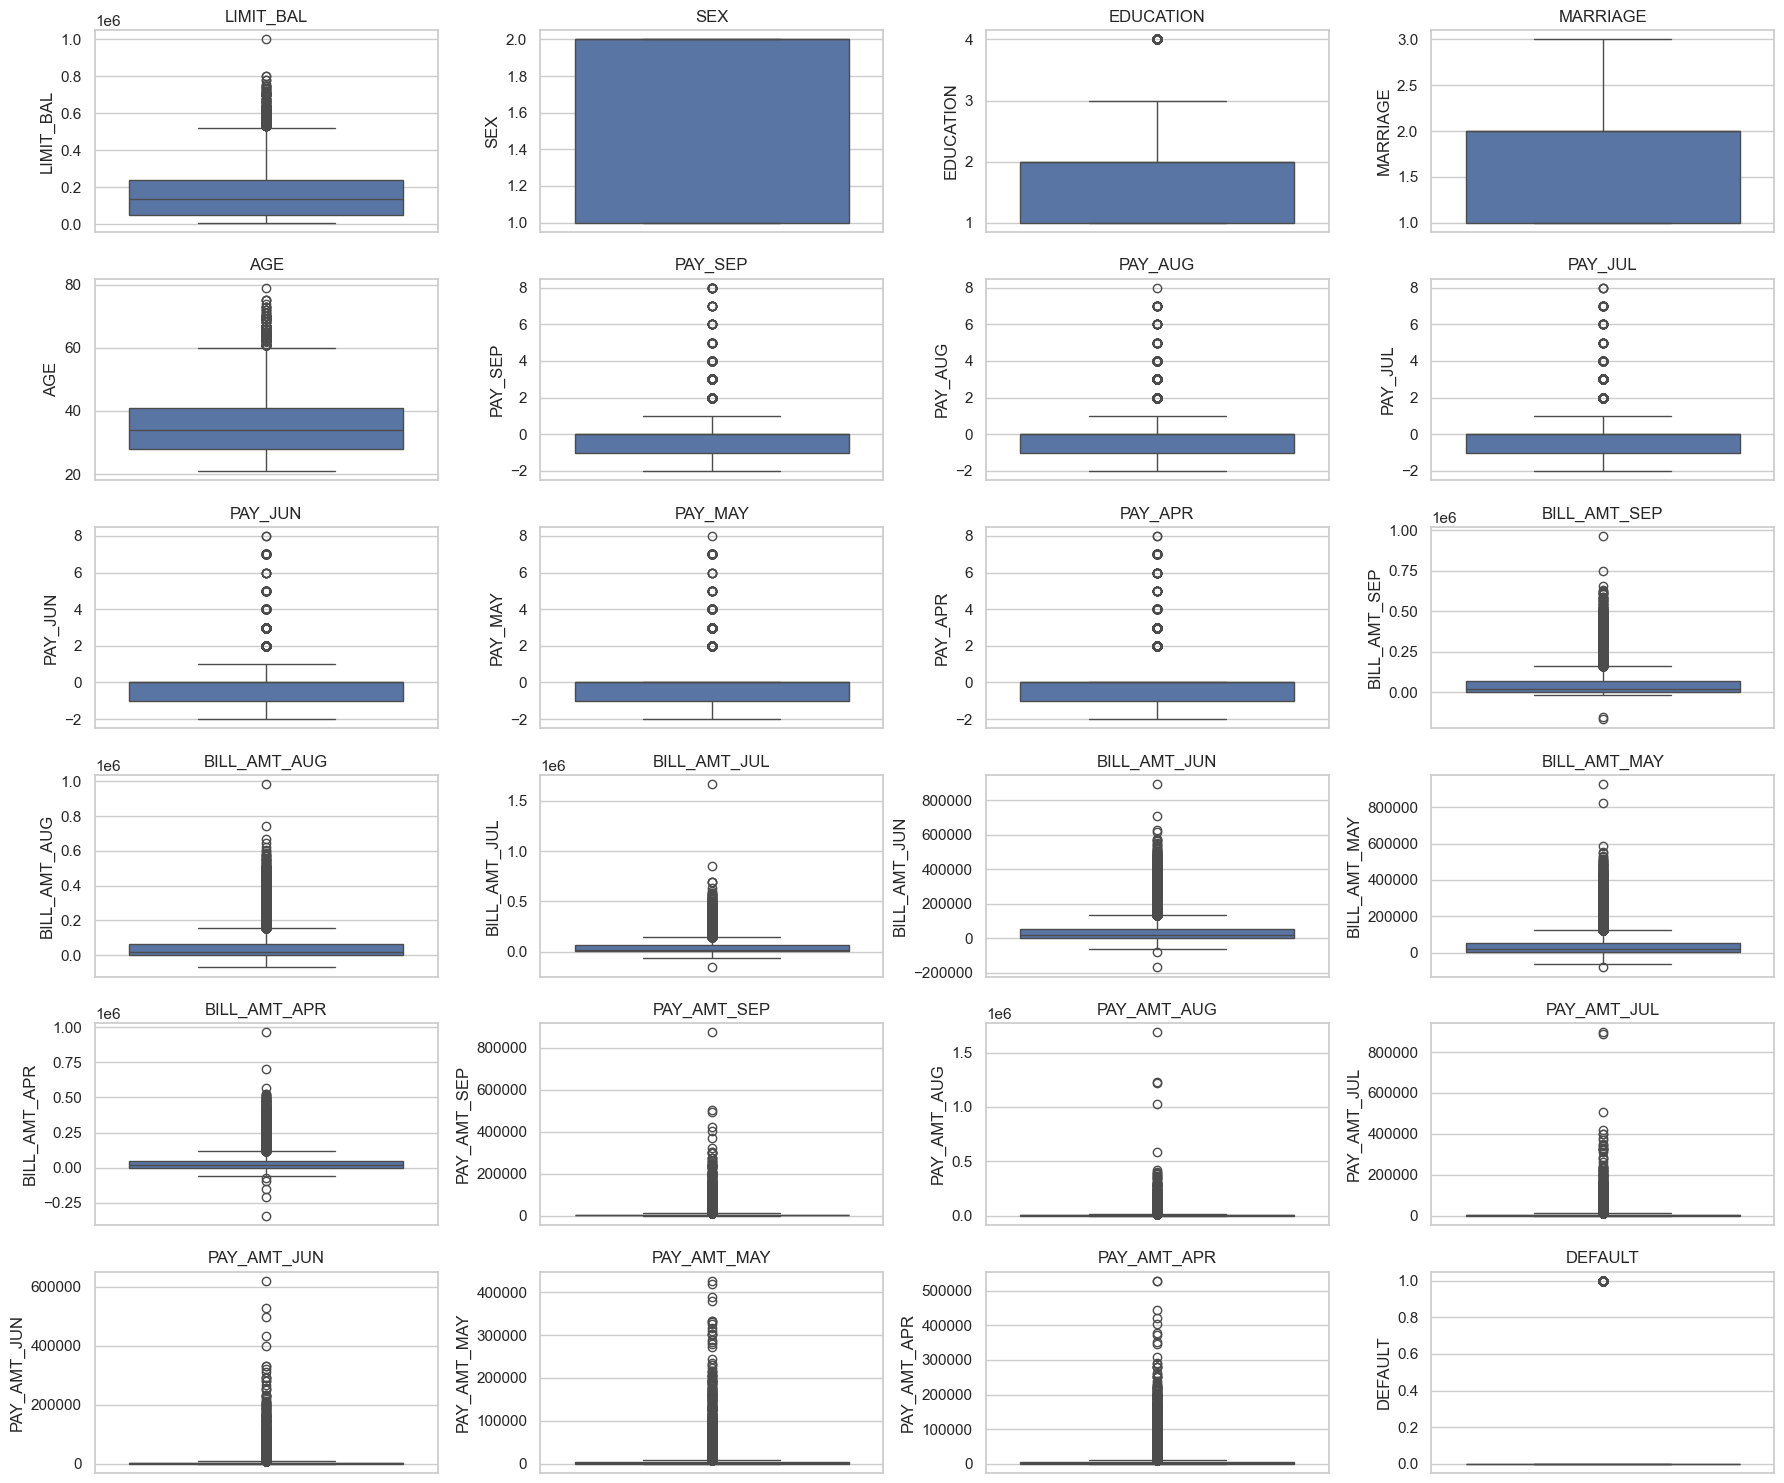

In [30]:
plt.figure(figsize=(18,15))

for i,col in enumerate(num_cols):

    plt.subplot(6,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()



The boxplots above reveal that several numerical variables contain noticeable outliers.

The variables **LIMIT_BAL**, **BILL_AMT_APR–BILL_AMT_SEP**, and **PAY_AMT_APR–PAY_AMT_SEP** exhibit a significant number of outliers. These variables represent customers' credit limits, monthly bill amounts, and payment amounts, where a small proportion of customers have values that are much higher than the majority.

- **Why Credit Datasets Naturally Contain Outliers**

Outliers are common in financial datasets because customers differ considerably in their financial capacity and spending behaviour. Some customers have exceptionally high credit limits, large outstanding balances, or make unusually large payments due to higher income levels or business activities. These values reflect real customer behaviour rather than data entry errors.

- **Why the Outliers Are Retained**
  
The outliers are retained because they represent genuine observations that provide valuable information about customer financial behaviour. Removing them could result in the loss of important patterns that help distinguish between low-risk and high-risk customers. Since the objective is to predict loan default, preserving these extreme but valid cases allows the machine learning model to learn from real-world financial variations.

## **CORRELATION ANALYSIS**

 Correlation measures the strength of the linear relationship between numerical variables.

A heatmap will help identify highly correlated variables, which may indicate multicollinearity.

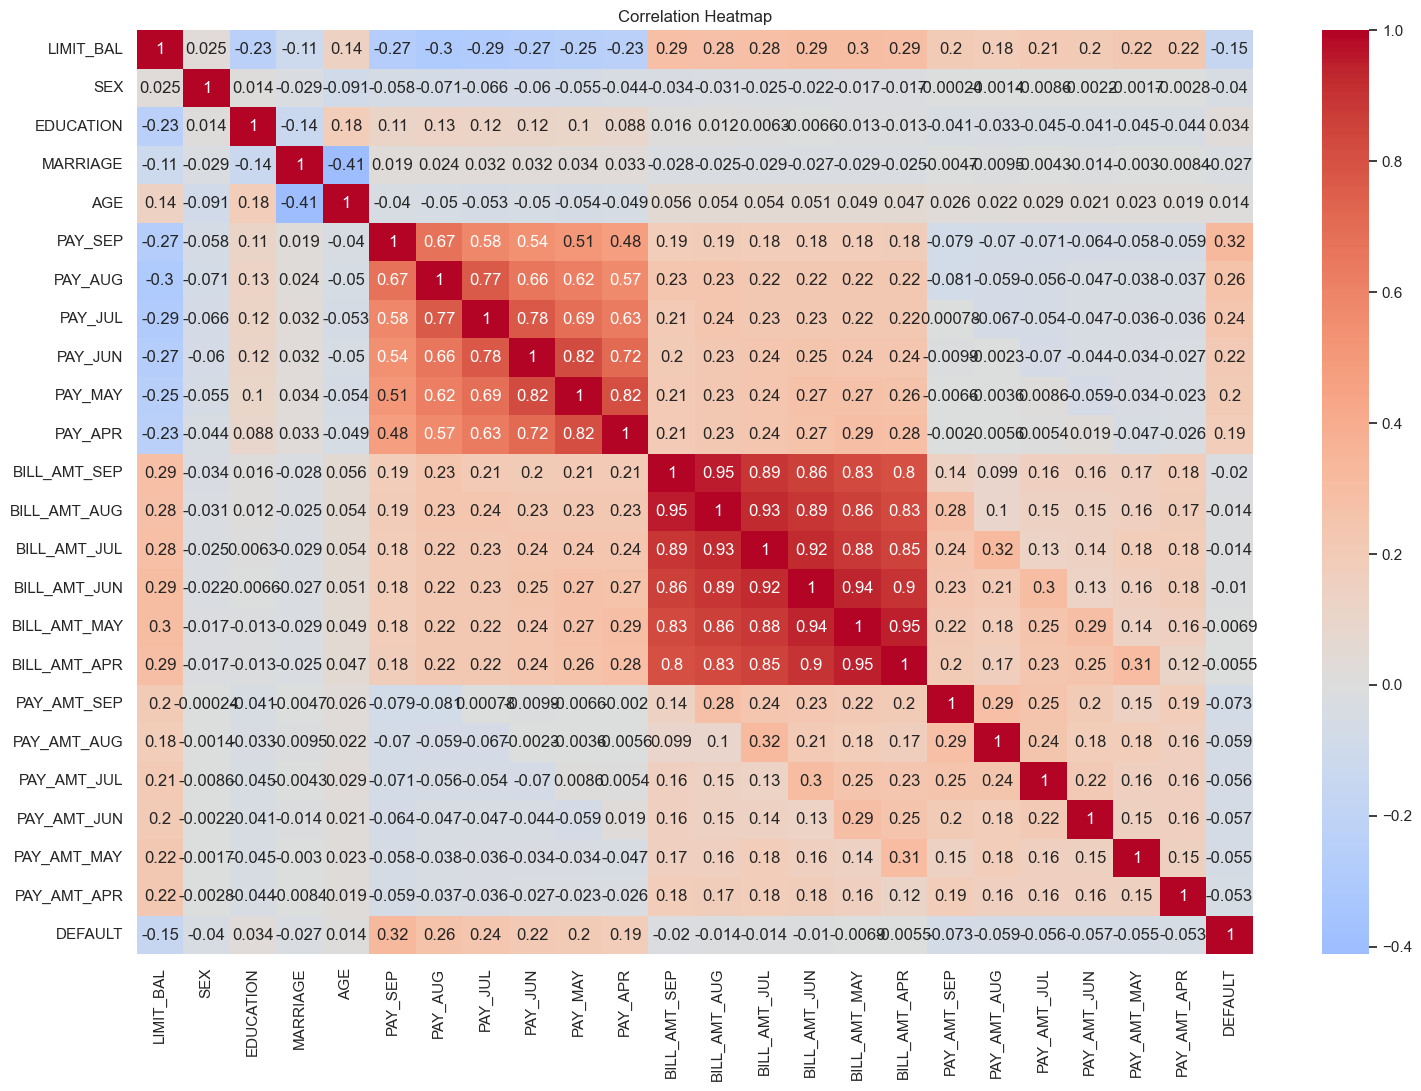

In [31]:
plt.figure(figsize=(18,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot = True
)

plt.title("Correlation Heatmap")

plt.show()


- **Positive Correlation**

The strongest positive correlations are observed among the **monthly bill amount variables (BILL_AMT_APR to BILL_AMT_SEP)**. This means that customers who have a high bill amount in one month are likely to have high bill amounts in the following months. This is expected because customers' spending habits are usually consistent over time.

A strong positive relationship is also observed among the **payment status variables (PAY_APR to PAY_SEP)** though not as strong as **(BILL_AMT_APR to BILL_AMT_SEP)**. Customers who delayed their payments in one month often continued to experience payment delays in subsequent months.

- **Negative Correlation**

The negative correlations only ranges from 0 to -0.4 which means that there are no strong negative linear relationships between any pair of variables.

Overall, there are no strong negative correlations in the dataset. Most negative relationships are weak.

- **Variables Correlated with Loan Default**

The variables most closely related to **DEFAULT** are the **payment status variables (PAY_APR to PAY_SEP)**. These variables show a positive correlation with **DEFAULT** with the highest value being 0.32, indicating that customers with a history of delayed payments are more likely to default on their loans.

On the other hand, variables such as **SEX**, **MARRIAGE**, **EDUCATION**, and **AGE** have very weak correlations with the target variable.

- **Insight**

Since no single feature has a very correlation with the target credit card default appears to be influenced by multiple factors rather than a single variable.

## **DEFAULT RATE BY GENDER**
This visualization compares the frequency of loan default between male and female customers.

It answers the question ,does Gender Influence Loan Default?

In [32]:
#This function will make the chart below easier to understand

df["GENDER"] = df["SEX"].replace({1: "Male", 2: "Female"})
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT,GENDER
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Female
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Male


In [33]:
default_by_gender = df.groupby(["GENDER", "DEFAULT"]).size().unstack().reset_index()
default_by_gender.rename(columns = {0:"Not Defaulted", 1:"Defaulted"}, inplace = True)
default_by_gender["Not Defaulted %"] = (default_by_gender["Not Defaulted"]/(default_by_gender["Not Defaulted"] + default_by_gender["Defaulted"])) * 100
default_by_gender["Defaulted %"] = 100 - default_by_gender["Not Defaulted %"]
default_by_gender

DEFAULT,GENDER,Not Defaulted,Defaulted,Not Defaulted %,Defaulted %
0,Female,14330,3761,79.21,20.79
1,Male,9005,2869,75.84,24.16


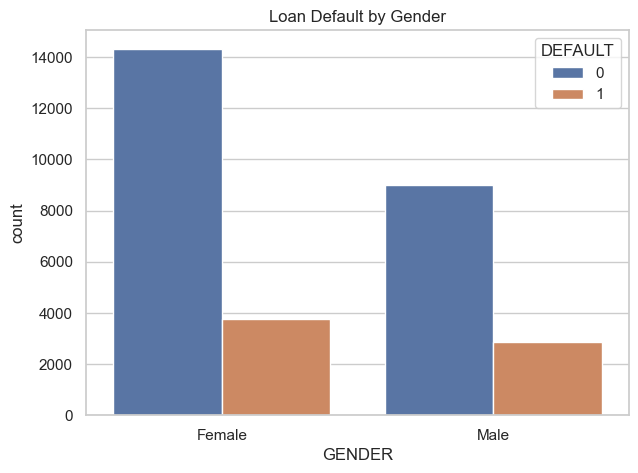

In [34]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="GENDER",
    hue="DEFAULT"
)

plt.title("Loan Default by Gender")

plt.show()

From the table and chart above , the following findings were made;
- There are more female customers in than male in the dataset.
- In both gender groups, the number of customers who **did not default (0)** is higher than those who **defaulted (1)**: 79.21% for females and 75.84% for males, compared to 20.79% and 24.16%.
- Although female customers have more default cases in terms of count, this is likely because there are more customers in that group overall.
- Based on the percentage breakdown and chat above, gender does not appear to have a strong influence on loan default.

**Insight**

The difference in loan default between the two gender groups is relatively small. This suggests that gender alone is not a strong predictor of whether a customer will default on a loan. Other factors, such as payment history and credit behaviour, are likely to have a greater impact on loan default.

## **DEFAULT BY EDUCATION**


In [35]:
df["EDUCATION_LEVEL"] = df["EDUCATION"].replace({
    1:"Graduate School",
    2:"University",
    3:"High School",
    4:"Others"
})

In [36]:
default_by_education = df.groupby(["EDUCATION_LEVEL", "DEFAULT"]).size().unstack().reset_index()
default_by_education.rename(columns = {0:"Not Defaulted", 1:"Defaulted"}, inplace = True)
default_by_education["Not Defaulted %"] = (default_by_education["Not Defaulted"]/(default_by_education["Not Defaulted"] + default_by_education["Defaulted"])) * 100
default_by_education["Defaulted %"] = 100 - default_by_education["Not Defaulted %"]
default_by_education

DEFAULT,EDUCATION_LEVEL,Not Defaulted,Defaulted,Not Defaulted %,Defaulted %
0,Graduate School,8531,2032,80.76,19.24
1,High School,3678,1237,74.83,25.17
2,Others,435,33,92.95,7.05
3,University,10691,3328,76.26,23.74


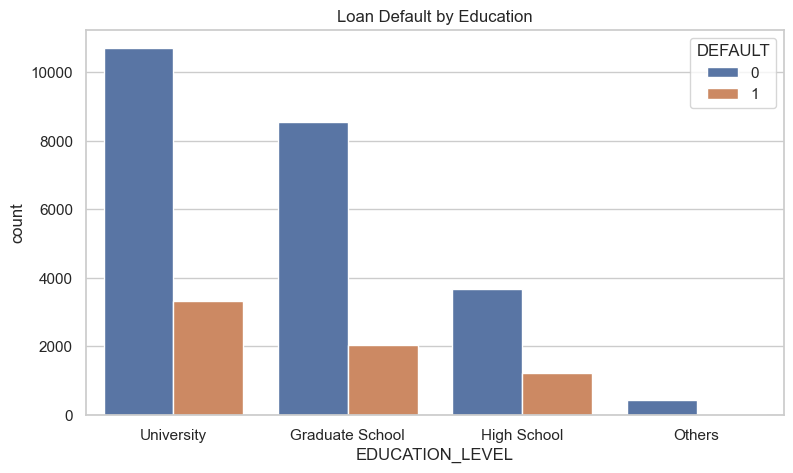

In [37]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="EDUCATION_LEVEL",
    hue="DEFAULT"
)

plt.title("Loan Default by Education")

plt.show()

The chart analysis and chat above compares loan default across different education levels. The following findings were made;

- Customers in **University level** make up the largest group in the dataset and also have the highest number of default cases.
- **Graduate School** has the second-largest number of customers and also records a noticeable number of defaults.
- **High School** has fewer customers and fewer default cases than Levels 1 and 2.
- **Others** has very few customers, so it is difficult to draw any meaningful conclusions about its default pattern.

From this chart alone, education appears to have **some association** with loan default. However, the higher number of defaults in Education Levels 1 and 2 is likely because these groups contain more customers overall, not necessarily because they are more likely to default.

**Insight**

Education here may provide some useful information when predicting loan default, but it does not appear to be one of the strongest factors. Financial factors such as payment history, credit limit, and previous repayment behaviour are likely to have a greater influence on whether a customer defaults.

## **DEFAULT BY MARITAL STATUS**

In [38]:
#This function will make the chart easier to understand

df["MARITAL_STATUS"] = df["MARRIAGE"].replace({
    1: "Married",
    2: "Single",
    3: "Others"
})
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT,GENDER,EDUCATION_LEVEL,MARITAL_STATUS
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female,University,Married
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female,University,Single
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female,University,Single
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Female,University,Married
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Male,University,Married


In [39]:
default_by_marital_status = df.groupby(["MARITAL_STATUS", "DEFAULT"]).size().unstack().reset_index()
default_by_marital_status.rename(columns = {0:"Not Defaulted", 1:"Defaulted"}, inplace = True)
default_by_marital_status["Not Defaulted %"] = (default_by_marital_status["Not Defaulted"]/(default_by_marital_status["Not Defaulted"] + default_by_marital_status["Defaulted"])) * 100
default_by_marital_status["Defaulted %"] = 100 - default_by_marital_status["Not Defaulted %"]
default_by_marital_status

DEFAULT,MARITAL_STATUS,Not Defaulted,Defaulted,Not Defaulted %,Defaulted %
0,Married,10442,3201,76.54,23.46
1,Others,288,89,76.39,23.61
2,Single,12605,3340,79.05,20.95


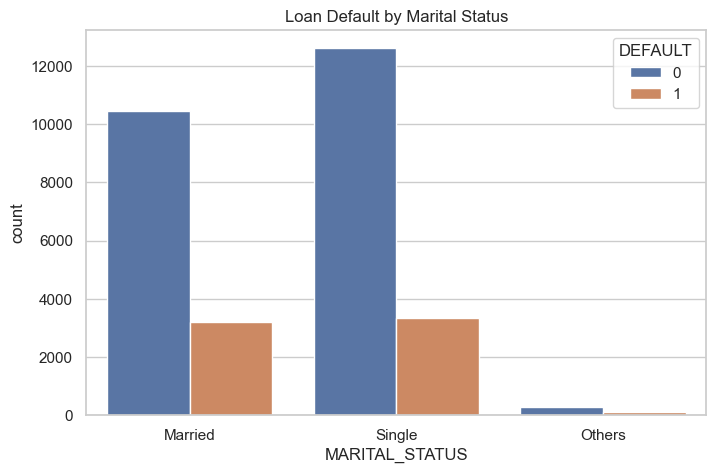

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="MARITAL_STATUS",
    hue="DEFAULT"
)

plt.title("Loan Default by Marital Status")
plt.show()


The table and chart above compare the loan default across different marital status groups.

- **Single** customers  make up the largest group in the dataset, followed by **Married customers**.
- In both groups, the number of customers who **did not default** is much higher than those who **defaulted**.
- **Others** has very few customers, making it difficult to draw meaningful conclusions for this group.
- The number of default cases is fairly similar for Married and single, suggesting that marital status alone does not have a strong influence on loan default.

**Insight**

Marital status does not appear to be a major factor in predicting loan default. Customers from both major marital groups show similar default patterns, indicating that financial behaviour, such as repayment history and credit management, is likely to be more important than marital status when assessing loan default risk.

## **AGE DISTRIBUTION**


Customer age can influence spending behaviour and repayment patterns.

Visualizing age helps identify the dominant customer age group. Histogram will be use for this .

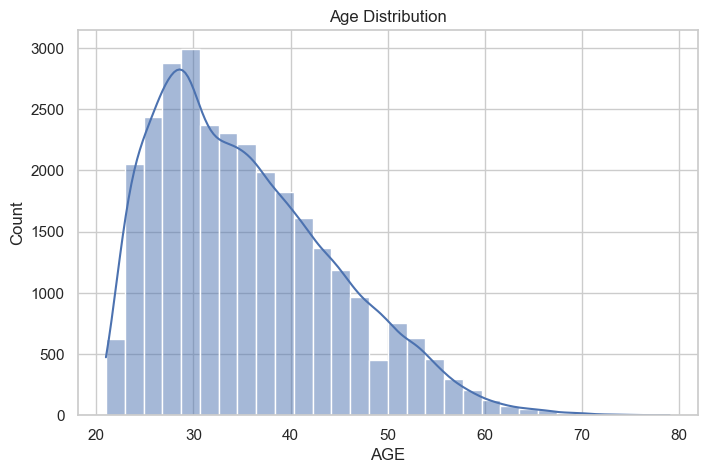

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["AGE"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()


The histogram above shows the distribution of customers' ages in the dataset. these findings were made;

- Most customers are between **25 and 40 years old**, with the highest concentration around the late twenties.
- The distribution is **right-skewed**, meaning there are many younger customers and fewer older customers.
- The number of customers gradually decreases as age increases, with very few customers above **60 years**.
- There are no unusual gaps in the distribution, suggesting that the age data is well distributed across the customer population.

**Insight**

The majority of the bank's credit card customers are young to middle-aged adults. Since this age group represents most of the customers, understanding their financial behaviour is important for predicting loan default. However, age alone may not be a strong predictor of default and should be considered alongside financial variables such as payment history, bill amounts, and credit limits.

## **CREDIT LIMIT DISTRIBUTION**

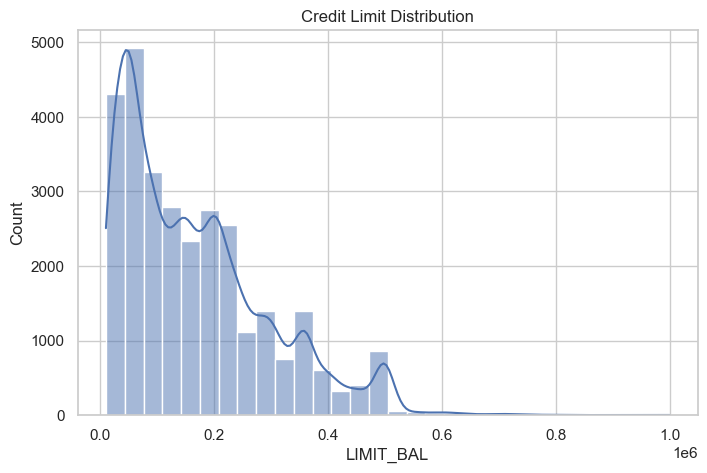

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["LIMIT_BAL"],
    bins=30,
    kde=True
)

plt.title("Credit Limit Distribution")

plt.show()


The histogram above shows the distribution of customers' credit limits (**LIMIT_BAL**).

- The distribution is **right-skewed**, meaning most customers have relatively low to moderate credit limits, while only a few customers have very high credit limits.
- The highest concentration of customers has credit limits below **200,000**, indicating that this is the most common credit limit range in the dataset.
- As the credit limit increases, the number of customers decreases significantly.
- A small number of customers have exceptionally high credit limits, creating the long tail on the right side of the distribution.

**Insight**

The bank has issued moderate credit limits to most of its customers, while only a small proportion of customers qualify for very high credit limits. These high-limit customers are likely to have stronger financial profiles and may be assessed differently during the credit approval process. The wide variation in credit limits suggests that **LIMIT_BAL** could be an important feature when predicting loan default.

## **CREDIT LIMIT AND LOAN DEFAULT**

A boxplot allows comparison of credit limits between customers who defaulted and those who did not.

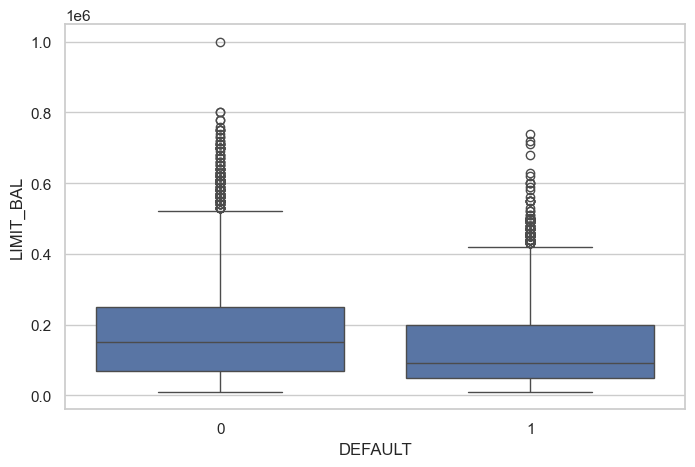

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="DEFAULT",
    y="LIMIT_BAL"
)

plt.show()


The boxplot above compares the credit limit (**LIMIT_BAL**) of customers who defaulted(1) and those who did not(0).

- Customers who **did not default (0)** generally have **higher credit limits** than customers who **defaulted (1)**.
- The median credit limit is higher for non-defaulting customers, indicating that they typically have greater access to credit.
- Both groups contain several outliers, showing that some customers have exceptionally high credit limits regardless of whether they defaulted.
- The wide spread of the data suggests that credit limits vary considerably among customers.

 **Insight**

The chart suggests that customers with **lower credit limits** are more likely to default on their loans than those with higher credit limits. This may be because customers with higher credit limits often have stronger credit histories and better financial standing. However, credit limit alone cannot fully explain loan default, so it should be considered together with other important factors such as payment history and bill amounts.

## **AGE AND CREDIT LIMIT**

Scatter plot will be used to show the relationship between Age and Credit Limit (LIMIT_BAL).

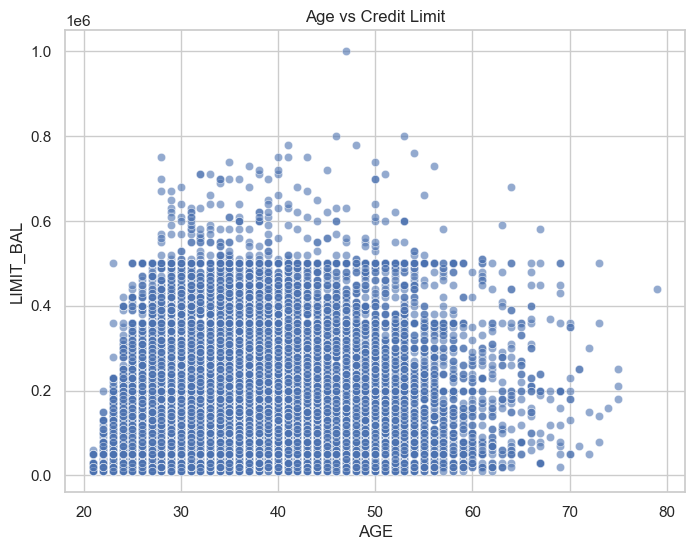

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="AGE",
    y="LIMIT_BAL",
    alpha=0.6
)

plt.title("Age vs Credit Limit")

plt.show()


The scatter plot shows the relationship between customers' age and their credit limit. The following findings were made;

- The points are widely scattered, indicating that there is **no strong relationship** between age and credit limit.
- Customers of different ages have both low and high credit limits, showing that age alone does not determine how much credit a customer receives.
- Most customers are between **25 and 50 years old**, and their credit limits vary across a wide range.
- A few customers have exceptionally high credit limits, but these are spread across different age groups rather than being concentrated in one particular age range.

**Relationship Between Age and Credit Limit**

The relationship between age and credit limit appears to be **weak**. As customers get older, there is no clear increase or decrease in their credit limits. This suggests that the bank considers other factors, such as income, repayment history, and creditworthiness, when deciding a customer's credit limit.

 **Insight**

Age alone is not a strong indicator of a customer's credit limit. Financial characteristics, such as payment history, outstanding bills, and previous repayment behaviour, are likely to have a greater influence on the amount of credit a customer is granted. Therefore, age should be used together with other financial variables when predicting loan default.

## **PAYMENT STATUS ANALYSIS**

The payment status variables (PAY_SEP, PAY_AUG, PAY_JUL, PAY_JUN, PAY_MAY, and PAY_APR) describe each customer's repayment behaviour over the previous six months.

These variables indicate whether a customer paid on time or delayed payment. Analysing their distributions helps identify common repayment patterns and provides insight into customers' credit behaviour.

Since repayment history is closely related to loan default, exploring these variables is essential before building a predictive model.

In [45]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT,GENDER,EDUCATION_LEVEL,MARITAL_STATUS
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female,University,Married
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female,University,Single
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female,University,Single
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Female,University,Married
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Male,University,Married


In [46]:
payment_cols = [
    "PAY_SEP",
    "PAY_AUG",
    "PAY_JUL",
    "PAY_JUN",
    "PAY_MAY",
    "PAY_APR"
]

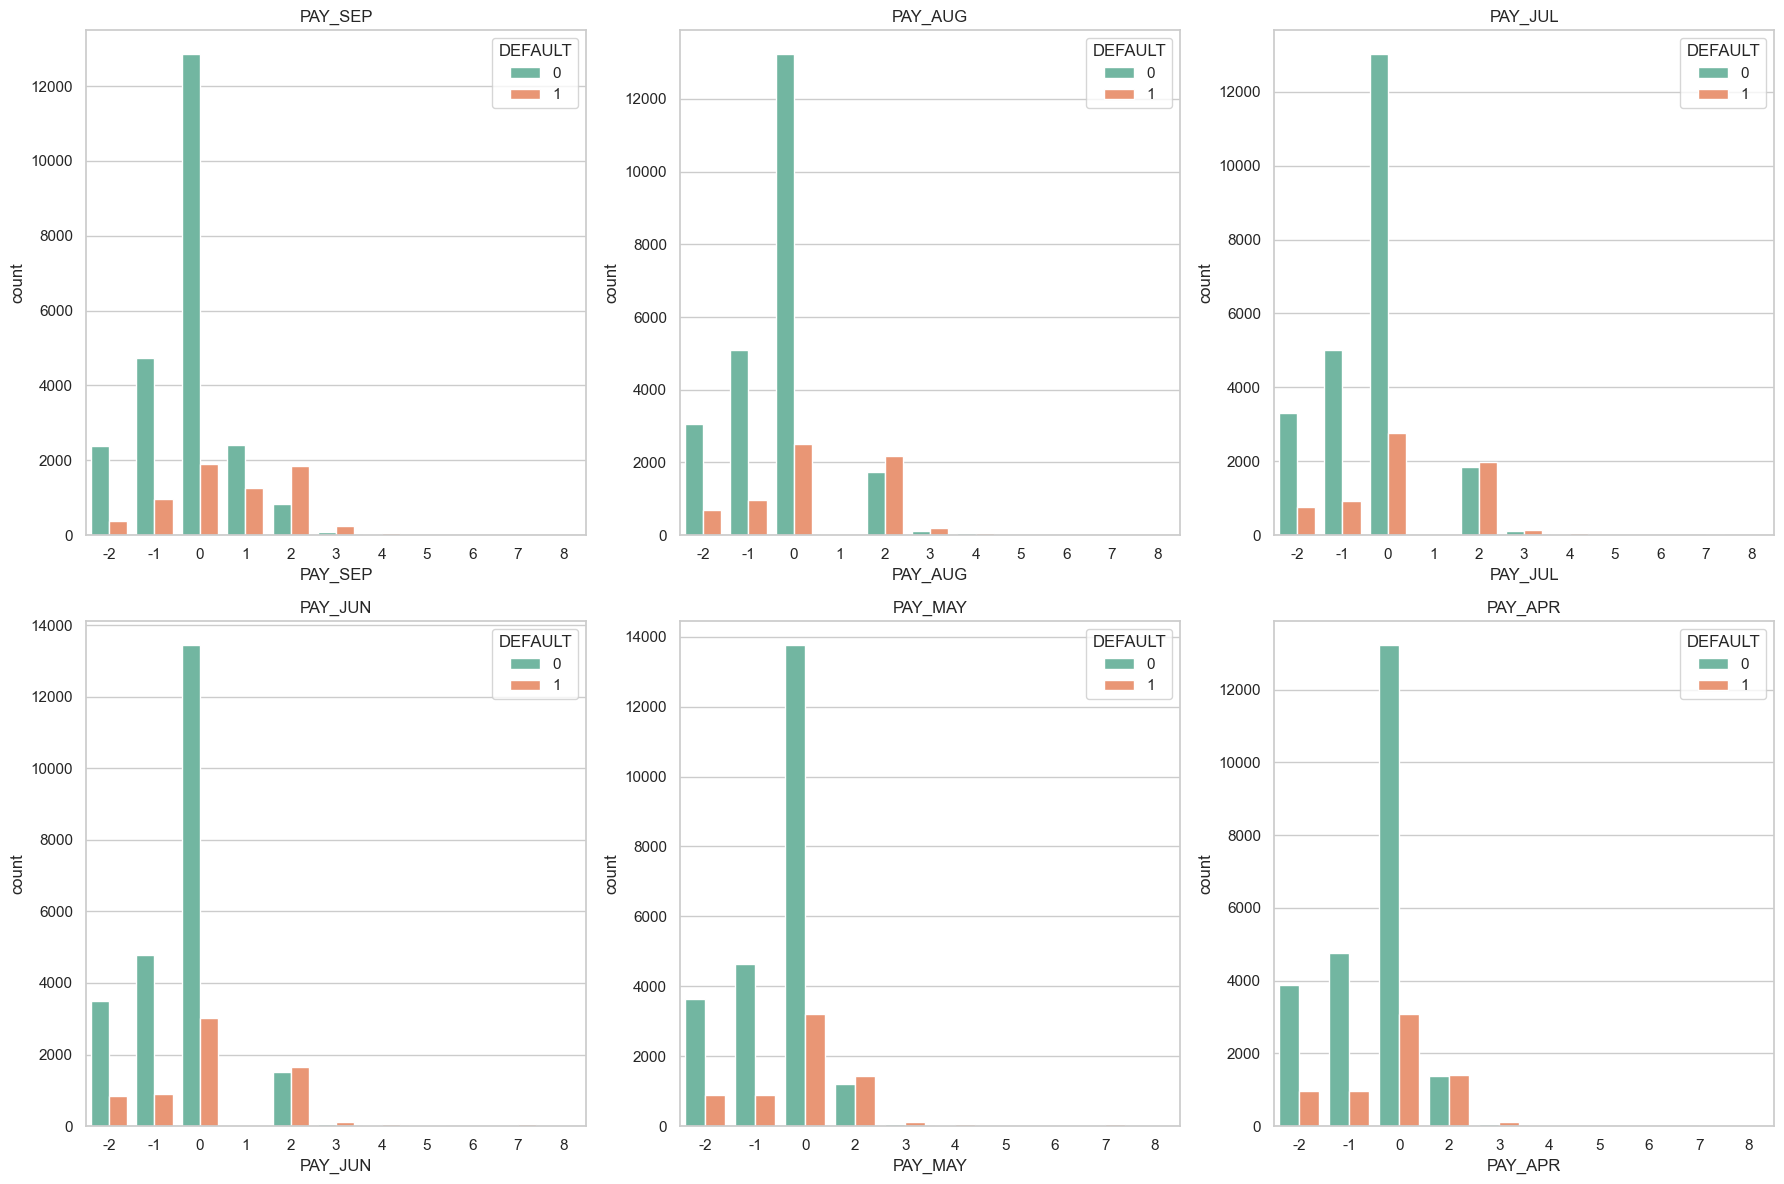

In [47]:
plt.figure(figsize=(18,12))

for i, col in enumerate(payment_cols):

    plt.subplot(2,3,i+1)

    sns.countplot(
        data=df,
        x=col,
        hue="DEFAULT",
        palette="Set2"
    )

    plt.title(col)

plt.tight_layout()
plt.show()
plt.show()


The countplots above show the distribution of customers' repayment status over the previous six months.

 **Key Findings**

- Most customers have repayment status values of **-1**, **0**, or **1**, indicating that the majority either paid their bills on time or had only a short payment delay.
- The number of customers decreases as the repayment delay increases. Very few customers have long payment delays, such as **4**, **5**, **6**, or higher.
- The repayment patterns are similar across all six months, suggesting that customers' payment behaviour remains relatively consistent over time.

 **Insight**

Repayment history is one of the strongest indicators of loan default. Customers who consistently delay their payments are more likely to experience financial difficulties and may have a higher risk of defaulting on future loans. Therefore, the payment status variables are expected to play a significant role in the machine learning model.



## **MONTHLY BILL AMOUNTS ANALYSIS**
 
 The bill amount variables (**BILL_AMT_APR** to **BILL_AMT_SEP**) represent the amount of each customer's credit card bill over the previous six months.

Visualizing these variables using boxplots helps identify the spread of the data, compare monthly billing patterns, and detect unusually high or low bill amounts. It also provides insight into customers' spending behaviour and whether extreme values are common in the dataset.

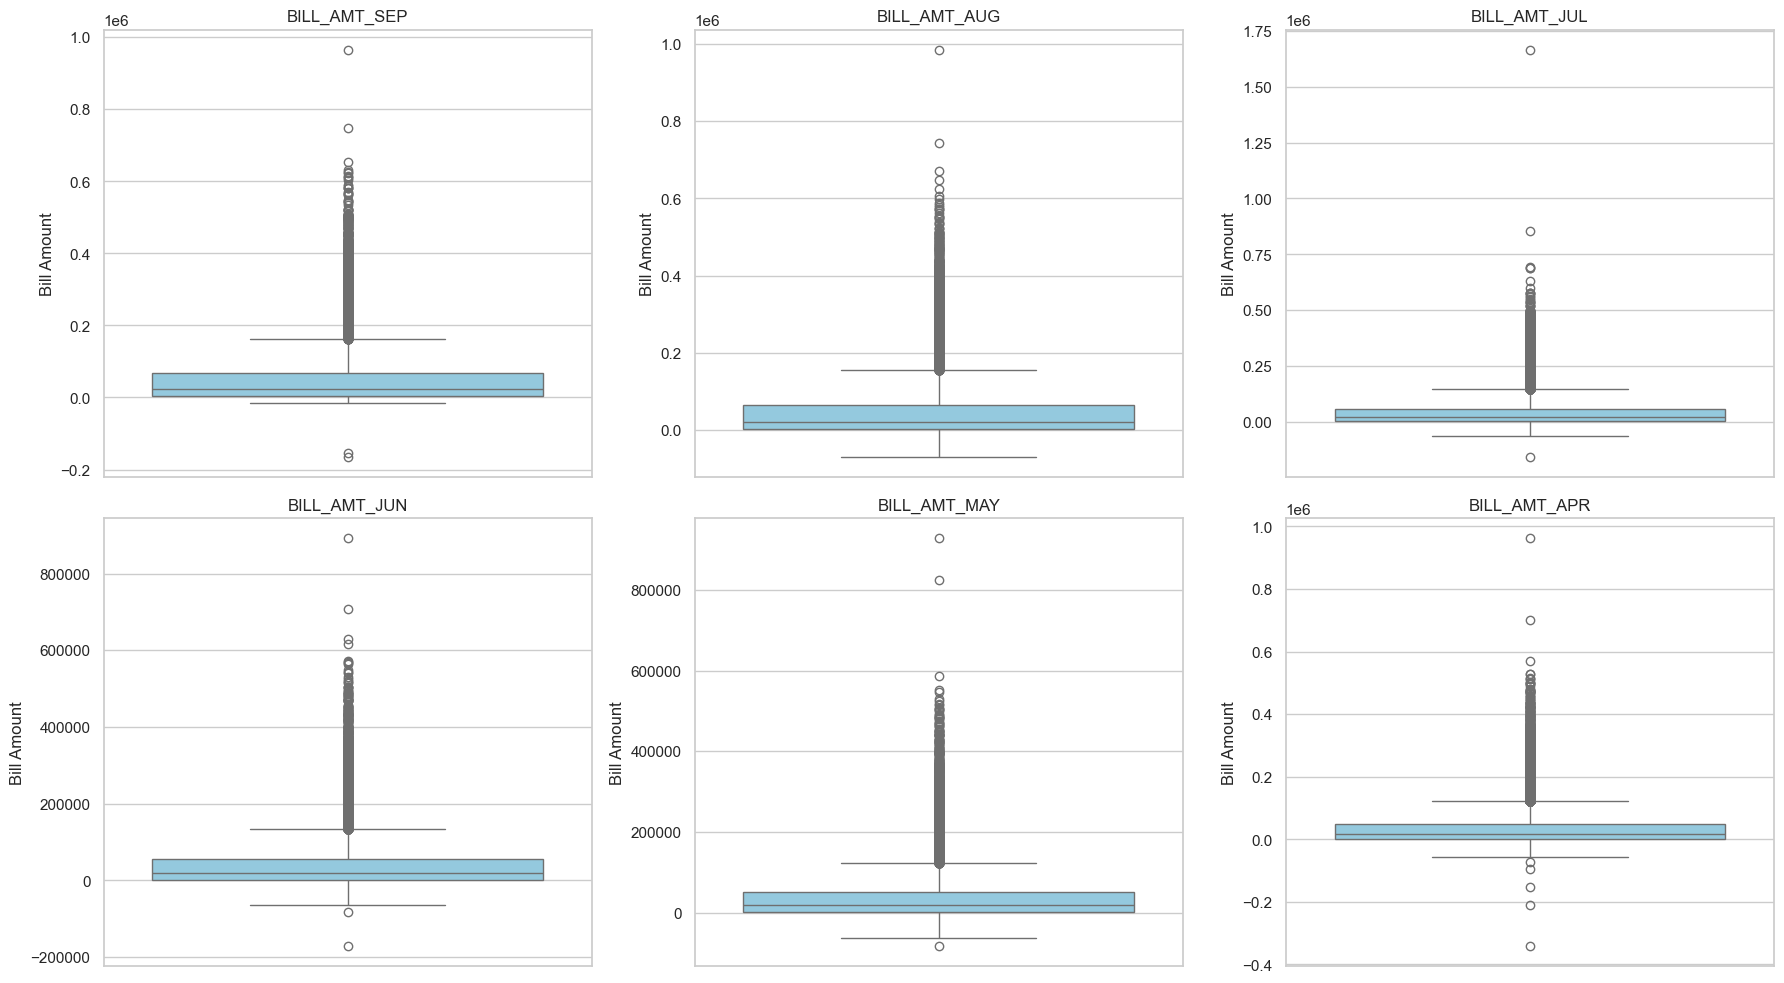

In [48]:
bill_cols = [
    "BILL_AMT_SEP",
    "BILL_AMT_AUG",
    "BILL_AMT_JUL",
    "BILL_AMT_JUN",
    "BILL_AMT_MAY",
    "BILL_AMT_APR"
]

plt.figure(figsize=(18,10))

for i, col in enumerate(bill_cols):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col], color="skyblue")

    plt.title(col)
    plt.ylabel("Bill Amount")

plt.tight_layout()
plt.show()


The boxplots show the distribution of customers' monthly bill amounts over the six-month period.

**Key Findings**

- The bill amount distributions are very similar across all six months, suggesting that customers' spending patterns remain fairly consistent over time.
- All six variables contain a large number of outliers. These represent customers with exceptionally high monthly bills compared to the majority of customers.
- Most customers have relatively low to moderate bill amounts, while only a small proportion have very high outstanding balances.
- The median bill amounts are fairly similar across the six months, indicating that there are no major changes in customers' overall spending behaviour during the observed period.


**Insight**

The presence of many high bill amounts suggests that some customers make significantly larger purchases or carry higher outstanding balances than others. These customers may require closer monitoring because high outstanding bills, especially when combined with poor repayment behaviour, can increase the risk of loan default.

The consistent pattern across all six months also indicates that customer spending behaviour is relatively stable, making the monthly bill amount variables useful predictors for a loan default prediction model.

## **MONTHLY PAYMENT AMOUNTS ANALYSIS**

The payment amount variables (**PAY_AMT_APR** to **PAY_AMT_SEP**) represent the amount paid by customers toward their credit card bills over the previous six months.

Histograms are used to examine the distribution of payment amounts, identify common repayment patterns, and detect unusually large payments. Understanding these patterns provides insight into customers' repayment behaviour and their ability to manage outstanding credit balances.

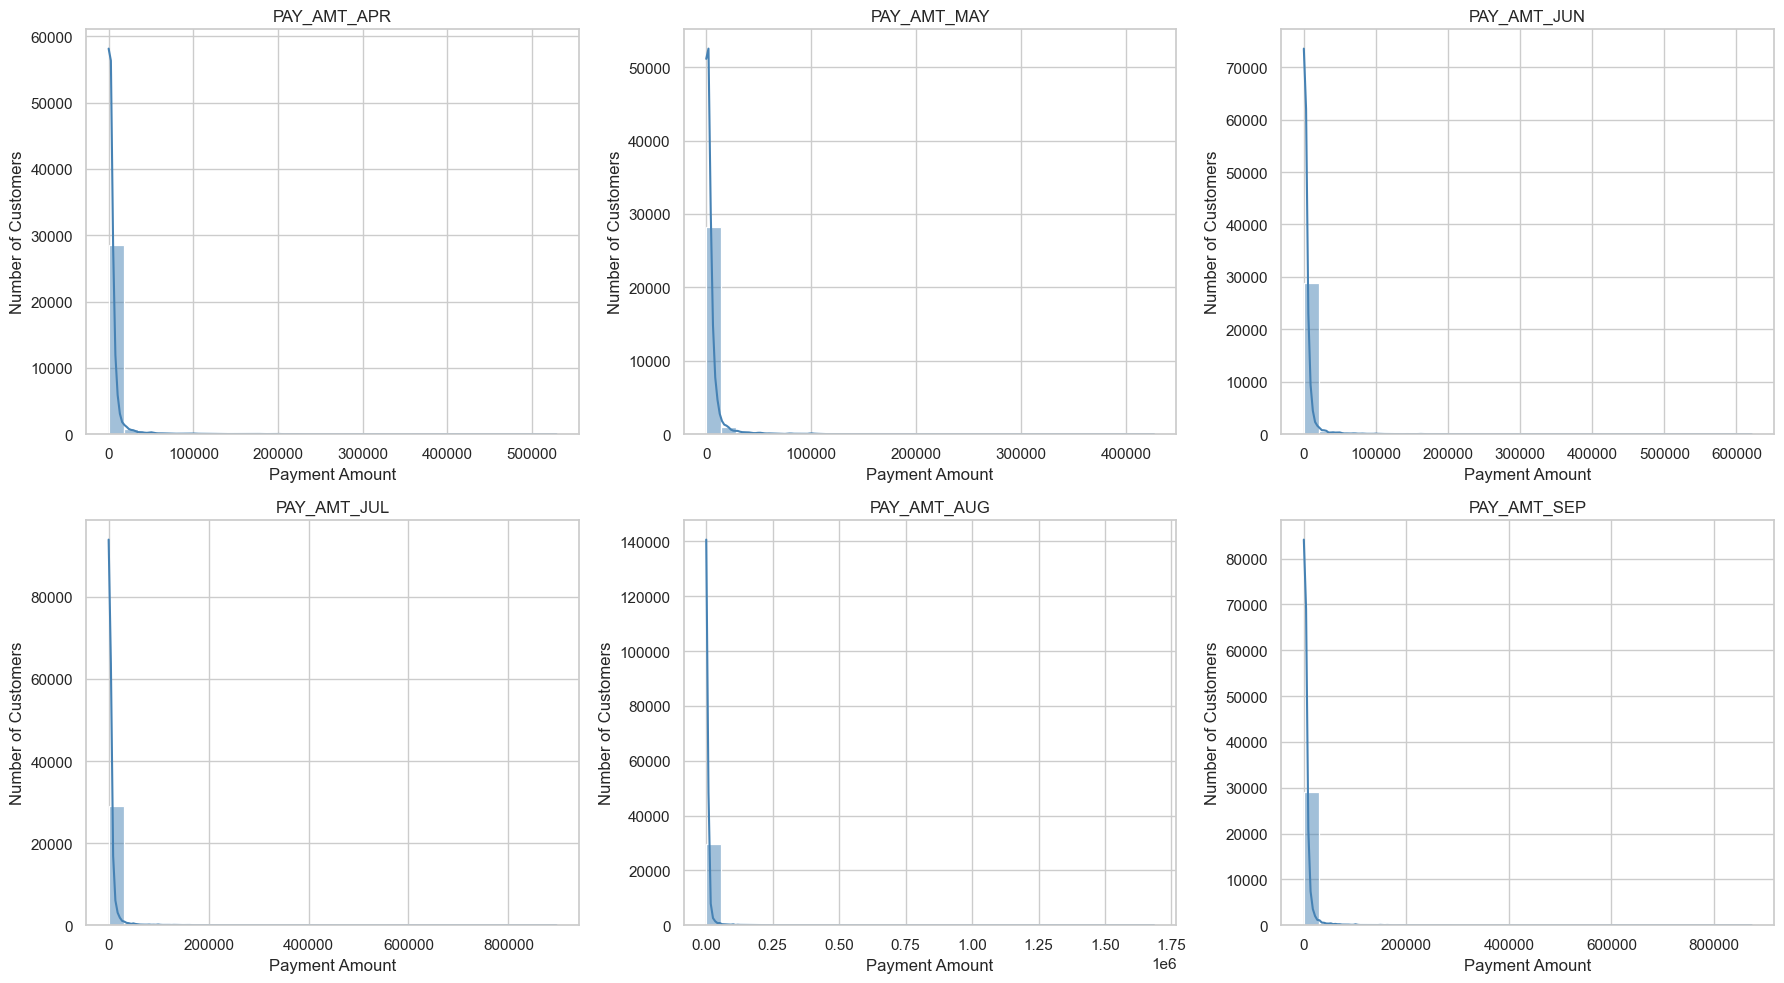

In [49]:
payment_amt_cols = [
    "PAY_AMT_APR",
    "PAY_AMT_MAY",
    "PAY_AMT_JUN",
    "PAY_AMT_JUL",
    "PAY_AMT_AUG",
    "PAY_AMT_SEP"
]

plt.figure(figsize=(18,10))

for i, col in enumerate(payment_amt_cols):

    plt.subplot(2,3,i+1)

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.title(col)
    plt.xlabel("Payment Amount")
    plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


The histograms above show the distribution of customers' monthly payment amounts over the six-month period.

**Key Findings**

- All six payment amount variables are **right-skewed**, meaning most customers make relatively small payments, while only a few make very large payments.
- The distributions are similar across all six months, suggesting that customers' repayment behaviour remains fairly consistent over time.
- A large proportion of customers make low to moderate monthly payments, while the number of customers decreases as the payment amount increases.
- A few customers make exceptionally large payments, creating long tails in the distributions. These high payments are expected in financial datasets and may represent customers paying off large balances.

**Insight**

The payment patterns indicate that most customers make regular payments of relatively modest amounts, while only a small number make very large repayments. Customers who consistently make timely and adequate payments are generally less likely to default, whereas customers who make low or irregular payments may face greater financial difficulty. Therefore, the monthly payment amount variables provide valuable information for predicting loan default.

## **PAIRWISE RELATIONSHIP**

Pairplots will be use here . It provide an overview of relationships between important numerical variables while simultaneously displaying class separation.

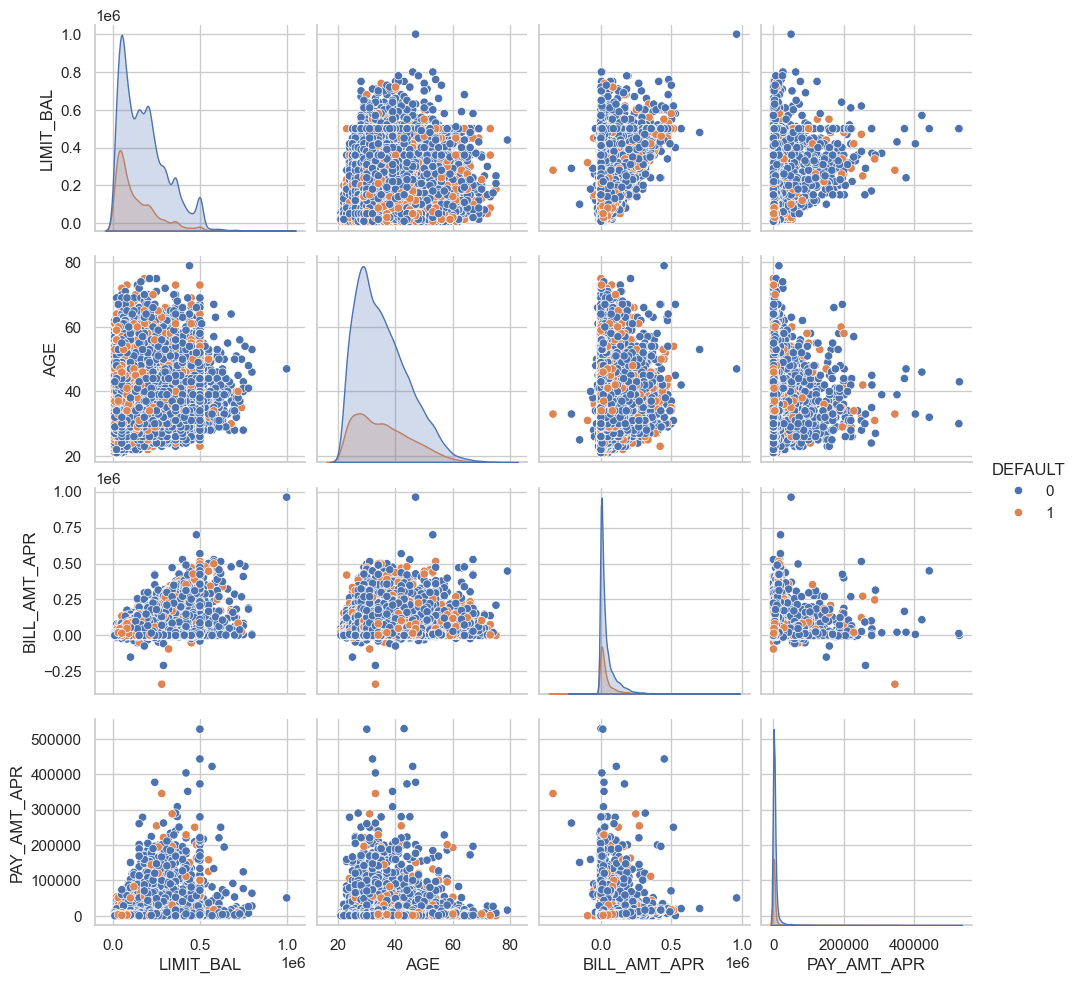

In [50]:
selected = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_APR",
    "PAY_AMT_APR",
    "DEFAULT"
]

sns.pairplot(
    df[selected],
    hue="DEFAULT"
)

plt.show()


The pairplot above shows the relationships between **Credit Limit (LIMIT_BAL)**, **Age (AGE)**, **April Bill Amount (BILL_AMT_APR)**, and **April Payment Amount (PAY_AMT_APR)**, with customers grouped by their loan default status.

**Key Findings**

- Most customers have **low to moderate credit limits**, while only a few customers have very high credit limits. This is evident from the distribution along the diagonal.
- The majority of customers are between **25 and 45 years old**, with fewer customers in the older age groups.
- There is a **positive relationship** between **LIMIT_BAL** and **BILL_AMT_APR**. Customers with higher credit limits generally tend to have higher monthly bill amounts.
- The relationship between **AGE** and the other financial variables appears **weak**, as customers of different ages have similar credit limits, bill amounts, and payment amounts.
- Customers who defaulted (orange points) are spread throughout the plots and overlap considerably with customers who did not default (blue points). This suggests that no single variable can clearly separate defaulters from non-defaulters.

 **Insight**

The pairplot shows that customer financial behaviour is more informative than demographic characteristics. Variables such as **credit limit**, **bill amount**, and **payment amount** appear to have stronger relationships with one another than **age**. Since customers who default overlap with those who do not, multiple variables will need to be combined in a machine learning model to accurately predict loan default rather than relying on a single feature.

The pairplot also indicates that the relationships between the selected variables are generally weak to moderate, reinforcing the need for machine learning algorithms that can capture complex interactions among multiple features rather than relying on simple linear relationships.

## **EDA (EXPLORATORY DATA ANALYSIS) SUMMARY**

 **Key Findings**

- The dataset is moderately imbalanced, with significantly more non-default cases than default cases.
- Most numerical variables exhibit right-skewed distributions, particularly credit limits and payment amounts.
- Credit-related variables contain numerous outliers, which are expected in financial datasets and therefore retained.
- Customers with lower credit limits appear more likely to default.
- Payment history variables show moderate relationships with default status, suggesting they are likely to be among the most predictive features.
- Age, education level, and marital status exhibit varying default patterns that may contribute useful predictive information.
- Correlation analysis indicates that bill amounts across different months are highly correlated, reflecting consistent spending behaviour over time

## **STEP 3:**  **MODEL BUILDING**

**Introduction**

The data has already been cleaned, explored, and visualized during the Exploratory Data Analysis (EDA) phase. This step is to build a machine learning model that can predict whether a customer is likely to default on their credit card payment.

This is a **binary classification** problem because the target variable has only two possible outcomes:

- **0** → Customer did not default.
- **1** → Customer defaulted.

The objective is to train a model that can accurately classify customers into these two categories based on their financial and demographic information.

The modelling process will follow these steps:

1. Prepare the feature and target variables.
2. Features encoding
3. Split the dataset into training and testing sets.
4. Applying SMOTE
5. Scale the features where necessary.
6. Checking class distribution
7. Training different machine learning models.
8. Evaluate each model using appropriate performance metrics.
9. Select the best-performing model for predicting loan default.

Also, the following models will be tested on the dataset:
- Logistic Regression Model
- Random Forest Classifier Model
- XGBoost
- K-Nearest Neighbors
- Support Vector Machine
  
Then compare them using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC
  
  Before now, the neccessary libraries were imported to aid the process.

In [51]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR,DEFAULT,GENDER,EDUCATION_LEVEL,MARITAL_STATUS
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female,University,Married
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female,University,Single
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female,University,Single
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Female,University,Married
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Male,University,Married


## **FEATURE AND TARGET VARIABLE SELECTION**
The features and target variable are selected for the model development.  

For the feature set(X), the **DEFAULT** column is dropped since it's the target. The **GENDER**, **EDUCATION_LEVEL**, and **MARITAL_STATUS** columns  also will be removed because they are duplicates of **SEX**, **EDUCATION** and **MARRIAGE** columns respectively.  

For the target variable (y),  the **DEFAULT** column is selected.


In [52]:
# Features
x = df.drop(columns = ["DEFAULT", "GENDER", "EDUCATION_LEVEL", "MARITAL_STATUS"])

# Target
y = df["DEFAULT"]

In [53]:
# Display 5 rows

x.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT_SEP,BILL_AMT_AUG,BILL_AMT_JUL,BILL_AMT_JUN,BILL_AMT_MAY,BILL_AMT_APR,PAY_AMT_SEP,PAY_AMT_AUG,PAY_AMT_JUL,PAY_AMT_JUN,PAY_AMT_MAY,PAY_AMT_APR
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [54]:
#Display the first 5 rows

y.head()

0    1
1    1
2    0
3    0
4    0
Name: DEFAULT, dtype: int64

In [55]:
# Check the shape

print("Features Shape:", x.shape)
print("Target Shape:", y.shape)

Features Shape: (29965, 23)
Target Shape: (29965,)



The dataset above contains **23 predictor variables** and **1 target variable**.

The predictor variables include customer demographic information, credit limits, repayment history, bill amounts, and payment amounts. These variables will be used by the machine learning algorithms to learn patterns associated with loan default.

The target variable (**DEFAULT**) contains the class labels that the model will predict.

## **FEATURE ENCODING**
Feature encoding converts categorical variables into numerical values that machine learning algorithms can process.  

Since the categorical features in this dataset are already numerically encoded into their resoective classes. Therefore, no additional feature encoding is required.

## **TRAIN-TEST SPLIT**
The dataset is divided into training and testing sets to evaluate the model's performance on unseen data. **The training set** is used to teach the model the underlying patterns in the data while **the testing set** is reserved for evaluating how well the model performs on unseen data.

**test_train_split** is first import from sklearn.model_selection library.  

80:20 split is used, where 80% of the data is allocated for training and 20% for testing. A random state is specified to make the results reproducible.

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=38,
stratify=y)

#Display dimension of x_train,x_test

print("Training Features:", x_train.shape)
print("Testing Features:", x_test.shape)


Training Features: (23972, 23)
Testing Features: (5993, 23)


The dataset above has been successfully divided into training and testing sets.

- **80% of the data** is used to train the machine learning models.
- **20% of the data** is reserved for testing.

The `stratify=y` parameter ensures that the proportion of customers who defaulted and those who did not default remains similar in both the training and testing sets. This helps produce a fair and reliable evaluation, especially when working with an imbalanced dataset.

## **APPLYING SMOTE**

The target variable was imbalanced, with significantly more non-default customers than default customers. To address this issue, **SMOTE (Synthetic Minority Oversampling Technique)** IS applied to the training data.

SMOTE generates synthetic samples of the minority class, resulting in a balanced training dataset while leaving the test data unchanged. This helps the machine learning models learn the characteristics of both classes more effectively and improves their ability to identify loan defaulters.



In [57]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Check the new class distribution
print(y_train_smote.value_counts())

DEFAULT
0    18668
1    18668
Name: count, dtype: int64


After applying SMOTE, both classes contained **18,668** observations, creating a balanced dataset for model training.

## **FEATURE SCALING**
The dataset contains variables with different numerical ranges. For example, **AGE** is measured in years, while **LIMIT_BAL** and the bill amounts are measured in much larger monetary values.

Algorithms such as **Logistic Regression** calculate distances and are sensitive to differences in feature scales. Standardizing the features ensures that each variable contributes equally during model training.

In contrast, tree-based algorithms such as **Decision Tree** and **Random Forest** do not require feature scaling because they split data based on feature values rather than distances.

For consistency, the features are scaled here and will be used when training Logistic Regression. The original (unscaled) data will be retained for the tree-based models.

This also helps transforms numerical values to a similar scale so that no feature dominates the others because of its magnitude.

The StandardScaler had been imported from the sklearn.preprocessing library and used to standardize the features by transforming them to have a mean of 0 and a standard deviation of 1.

In [58]:
# Create an instance

scaler = StandardScaler()

#fit on the data
x_train_smote = scaler.fit_transform(x_train_smote)
x_test = scaler.transform(x_test)

In [59]:
x_train_smote 

array([[ 1.64013617, -1.00936461, -1.08828447, ...,  1.16145653,
         5.60233479,  2.71363205],
       [ 1.00410424,  0.99072227, -1.08828447, ..., -0.29524517,
        -0.23467653, -0.25110892],
       [-0.42696761,  0.99072227,  0.34172148, ..., -0.29524517,
        -0.30909998, -0.28978001],
       ...,
       [-1.06299954, -1.00936461,  0.34172148, ..., -0.26385325,
        -0.26643154, -0.27588158],
       [-0.82448757,  0.99072227, -1.08828447, ..., -0.225979  ,
        -0.24301317, -0.23933386],
       [-0.82448757, -1.00936461, -1.08828447, ..., -0.24724685,
        -0.27363137, -0.28643409]], shape=(37336, 23))

In [60]:
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: DEFAULT, Length: 29965, dtype: int64

## **MODELS**

## **1. LOGISTIC REGRESSIONAL MODEL**

**Introduction**

Logistic Regression is one of the most widely used machine learning algorithms for binary classification problems.

Since the target variable (**DEFAULT**) has only two possible outcomes (Default or No Default), Logistic Regression is also an appropriate baseline model.

Although it is a relatively simple algorithm, it provides a good benchmark for evaluating the performance of more complex models such as Decision Tree and Random Forest.


**Training the Logistic Regression Model**

The model is trained using the standardized training data because Logistic Regression performs better when the input features are on a similar scale.

The model learns the relationship between the predictor variables and the target variable so that it can predict whether a customer is likely to default.

In [61]:
## Logistic Regression Model Validation Using Stratified 5-Fold Cross-Validation

cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=38)

pipeline = Pipeline([("smote", SMOTE(random_state=42)),("scaler", StandardScaler()),("model", LogisticRegression(class_weight="balanced",
max_iter=1000,random_state=38))])

scores = cross_val_score(pipeline,x_train,y_train,cv=cv,scoring="f1")
log_reg = LogisticRegression(class_weight="balanced",random_state=38,max_iter=1000)

print(scores)
print("Average F1:", scores.mean())

# Training the model
log_reg.fit(x_train_smote, y_train_smote)

[0.44900954 0.46165084 0.43452381 0.44990689 0.44754219]
Average F1: 0.44852665276426257


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,38
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



**Making Predictions**

After training the model, predictions were made on the testing dataset.

Two types of predictions are generated:

- Predicted class labels (0 or 1)
- Predicted probabilities, which are useful for plotting the ROC Curve.

In [62]:
# Predicted class labels
y_pred_log = log_reg.predict(x_test)

# Predicted probabilities
y_prob_log = log_reg.predict_proba(x_test)[:,1]

y_pred = (y_prob_log >= 0.41).astype(int)


## **Model Evaluation**

To assess the performance of the model, several classification metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Each metric provides different information about the model's performance.

In [63]:
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.698
Precision: 0.383
Recall   : 0.597
F1 Score : 0.467


From the above,

- **Accuracy** measures the overall proportion of correctly classified customers.
- **Precision** indicates how many customers predicted as defaulters actually defaulted.
- **Recall** measures the model's ability to correctly identify customers who truly defaulted.
- **F1-Score** balances Precision and Recall, making it particularly useful when working with imbalanced datasets such as loan default prediction.

A higher value for these metrics indicates better model performance.

- The Logistic Regression model achieved an **accuracy of 69.8%**, meaning it correctly classified approximately 70 out of every 100 customers. While this appears to be a good result, accuracy alone is not sufficient for evaluating a loan default model because the dataset contains many more non-defaulting customers than defaulting customers.

- The model achieved a **precision of 38.3%**, indicating that when it predicts a customer will default, it is correct about 38% of the time.

  
- However, the **recall is only 59..7%**, meaning the model identifies  about 60 out of every 100 customers who actually default. 

- The **F1-score of 46.7%** reflects the balance between precision and recall. The relatively low F1-score indicates that although the model has good accuracy, its ability to detect defaulting customers is limited.

## **Classification Report**

The classification report provides a detailed summary of the model's performance for each class.

It includes Precision, Recall, F1-Score, and the number of observations for both default and non-default customers.

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.59      0.71      4667
           1       0.33      0.70      0.45      1326

    accuracy                           0.62      5993
   macro avg       0.60      0.65      0.58      5993
weighted avg       0.75      0.62      0.65      5993





The Logistic Regression model above achieved an **overall accuracy of 62%**, indicating that it correctly classified approximately 62% of the customers.

For **Class 0 (No Default)**, the model performed well, achieving a **precision of 87%**, a **recall of 59%**, and an **F1 score of 0.71**. This shows that the model is effective at identifying customers who are unlikely to default.

For **Class 1 (Default)**, the model achieved a **precision of 33%**, a **recall of 70%**, and an **F1 score of 0.45**. The high recall indicates that the model successfully identified most customers who defaulted. However, the low precision suggests that many customers who did not default were incorrectly classified as defaulters, resulting in a high number of false positives.

Overall, the model provides a reasonable baseline for loan default prediction. While it performs well in detecting the majority class, its performance on the minority class remains limited. The weighted F1 score of **0.65** indicates moderate overall performance, suggesting that more advanced models such as Random Forest and XGBoost may achieve a better balance between precision and recall, leading to improved prediction of default cases.

 **Insight**

The model prioritizes identifying potential defaulters by achieving a high recall for the default class. This approach reduces the risk of missing customers who are likely to default but increases the number of false alarms. In a financial setting, this trade-off may be acceptable because identifying potential defaulters is often more important than incorrectly flagging some low-risk customers.



In [65]:
#CONFUSION MATRIX

lcm = confusion_matrix(y_test, y_pred)
lcm


array([[2766, 1901],
       [ 398,  928]])

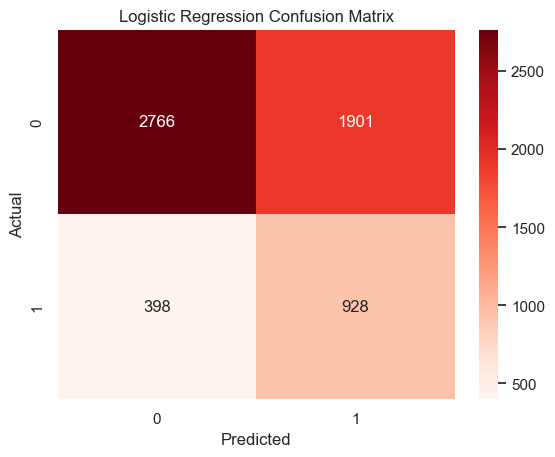

In [66]:
#VISUALIZING THE CONFUSION MATRIX FOR LOGISTIC REGRESSION

sns.heatmap(lcm, annot=True, cmap="Reds", fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

0=negative class, 1= positive class

**True Positive (TP = 930):** The number of loan defaulters that the model correctly predicted as loan defaulters.

**False Negative (FN = 400):** The number of loan defaulters that the model incorrectly predicted as non-loan defaulters.

**True Negative (TN = 2800):** The number of non-loan defaulters that the model correctly predicted as non-loan defaulters.

**False Positive (FP = 1900):** The number of non-loan defaulters that the model incorrectly predicted as loan defaulters.


In [67]:
#TO CALCULATE FOR PRECISION( this answers the question, of all the predicted as defaulter, how many of them are actually defaulters?)
# precision = TP/(TP+FP) 

930/(930+1900)


0.3286219081272085

In [68]:
# TO CALCULATE FOR RECALL(This answers the question ,of all the default predicted , how many did the model actually predicted or catch?).
#Recall TP/(TP+FN)

930/(930+400)


0.6992481203007519



The confusion matrix shows that the Logistic Regression model correctly classified approximately **2,800 non-default customers (True Negatives)** and **930 default customers (True Positives)**.

However, the model incorrectly classified about **1,900 non-default customers as defaulters (False Positives)** and failed to identify approximately **400 actual defaulters (False Negatives)**.

Overall, the model demonstrates a strong ability to identify customers who are likely to default, as reflected by the relatively high number of true positives and the low number of false negatives. However, the large number of false positives indicates that many low-risk customers are incorrectly flagged as high-risk. This suggests that while the model is effective at detecting potential defaults, it sacrifices precision by generating a considerable number of false alarms.

## **ROC (Receiver Operating Characteristics Curve)**

It shows the relationship bw the FPR(false positive rate) and TPR(True positive rate). it works with probability

In [69]:

y_prob_log = log_reg.predict_proba(x_test)[:,1]

log_auc = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC Score:", log_auc)

ROC-AUC Score: 0.7070622137203516


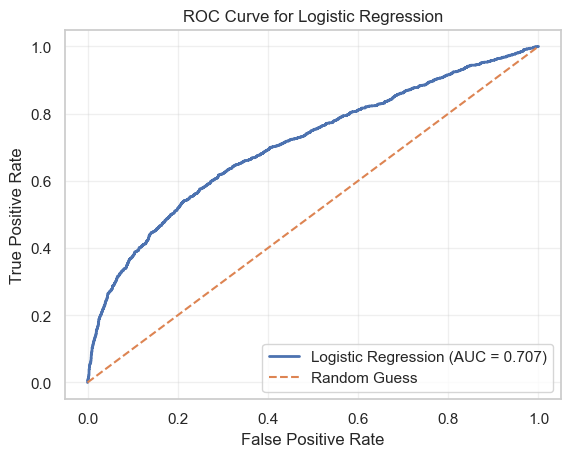

In [70]:
##VISUALIZING THE ROC-AUC SCORE

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.plot(fpr, tpr, linewidth=2,
         label=f'Logistic Regression (AUC = {log_auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--',
         label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

The Logistic Regression model achieved a **ROC-AUC score of 0.707**, indicating a **fair ability** to distinguish between loan defaulters and non-loan defaulters. Since the ROC curve lies above the random guess line, the model performs better than random classification. However, the AUC value suggests there is still room for improvement in accurately identifying customers who are likely to default

## **RANDOM FOREST MODEL** 


Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is well suited for classification tasks because it can capture complex relationships within the data and provide robust predictions. In this project, the Random Forest model is trained on the SMOTE-balanced training dataset to classify customers as either loan defaulters or non-loan defaulters.



In [71]:

## Train the Random Forest Model

forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42)

forest.fit(x_train_smote, y_train_smote)


,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
## Obtain Default Probabilities

prob = forest.predict_proba(x_test)[:, 1]

In [73]:
### Threshold Optimization: The prediction threshold was adjusted to maximize the F1 score for the default class.

thresholds = np.arange(0.20, 0.81, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    pred = (prob >= t).astype(int)
    score = f1_score(y_test, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.4400000000000002
Best F1: 0.527891156462585


## **Classification Report**

The classification report provides a detailed summary of the model's performance for each class.

It includes Precision, Recall, F1-Score, and the number of observations for both default and non-default customers.

In [74]:
rf_pred = (prob >= best_threshold).astype(int)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4667
           1       0.48      0.59      0.53      1326

    accuracy                           0.77      5993
   macro avg       0.68      0.70      0.69      5993
weighted avg       0.79      0.77      0.78      5993




The Random Forest model achieved an **overall accuracy of 77%**, indicating that it correctly classified 77% of the customers in the test dataset.

For **Class 0 (No Default)**, the model performed well, achieving a **precision of 87%**, a **recall of 82%**, and an **F1 score of 0.85**. This demonstrates that the model is highly effective at identifying customers who are unlikely to default.

For **Class 1 (Default)**, the model achieved a **precision of 48%**, a **recall of 59%**, and an **F1 score of 0.53**. While the model identified more than half of the actual defaulters, its performance on the minority class remains moderate, with room for improvement.

Overall, the Random Forest model outperformed the baseline Logistic Regression model, achieving a **weighted F1 score of 0.78** and a **macro F1 score of 0.69**. However, the F1 score for the default class (**0.53**) indicates that the model still struggles to accurately identify defaulters. Therefore, more advanced ensemble methods such as XGBoost will be explored to further improve the prediction of loan defaults.

**Insight**

The Random Forest model provides better overall classification performance than Logistic Regression, particularly for non-default customers. However, its ability to identify loan defaulters is still limited, suggesting that further model optimization or the use of more advanced boosting algorithms may be required to achieve a higher F1 score for the default class.

# **Confusion Matrix**




In [75]:
rcm = confusion_matrix(y_test, rf_pred)

print(rcm)

[[3829  838]
 [ 550  776]]


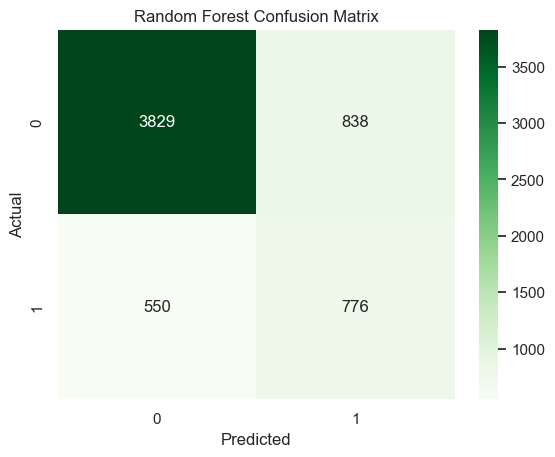

In [76]:
sns.heatmap(rcm, annot=True, cmap="Greens", fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.display_labels=(["No Default", "Default"])
plt.title("Random Forest Confusion Matrix")
plt.show()

True Negatives (TN): ≈ 3,800

False Positives (FP): ≈ 840

False Negatives (FN): ≈ 550

True Positives (TP): ≈ 780



In [77]:
#TO CALCULATE FOR PRECISION( this answers the question, of all the predicted as defaulter, how many of them are actually defaulters?)
# precision = TP/(TP+FP) 

780/(780+840)


0.48148148148148145

In [78]:
# TO CALCULATE FOR RECALL(This answers the question ,of all the default predicted , how many did the model actually predicted or catch?).
#Recall TP/(TP+FN)

780/(780+550)


0.5864661654135338

The Random Forest model correctly classified approximately **3,800 non-loan defaulters (True Negatives)** and **780 loan defaulters (True Positives)**. However, it incorrectly classified about **840 non-loan defaulters as loan defaulters (False Positives)** and **550 loan defaulters as non-loan defaulters (False Negatives)**.

Overall, the model demonstrates strong performance in identifying non-loan defaulters while achieving a moderate ability to detect loan defaulters. Although the number of correctly identified defaulters is reasonable, reducing the false negatives and false positives would further improve the model's effectiveness in predicting loan defaults.


## **ROC (Receiver Operating Characteristics Curve)**

It shows the relationship bw the FPR(false positive rate) and TPR(True positive rate). it works with probability


In [79]:
forest_prob = forest.predict_proba(x_test)[:,1]

auc_score = roc_auc_score(y_test, forest_prob)
auc_score


0.7689131610185569



The Random Forest model achieved a **ROC-AUC score of 0.769**, indicating a good ability to distinguish between customers who are likely to default and those who are not.

A ROC-AUC score of **0.769** means that the model has approximately a **76.9% chance** of correctly ranking a randomly selected default customer higher than a randomly selected non-default customer. This suggests that the model performs better than random guessing and has a good level of discrimination, although there is still room for improvement.

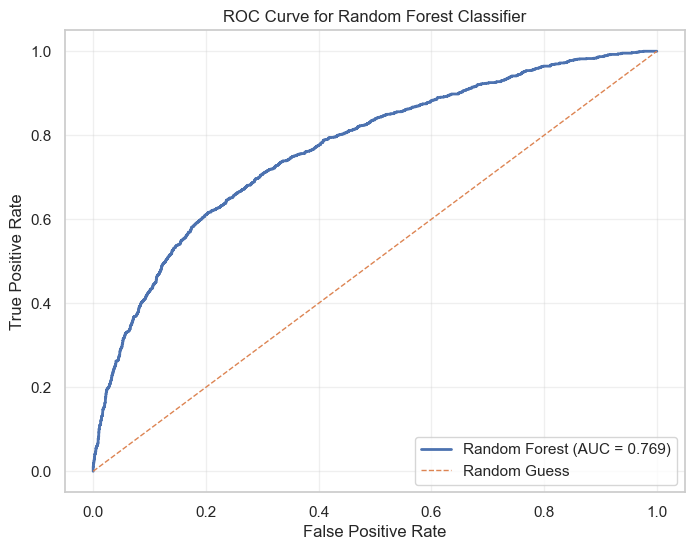

In [80]:
#VISUALIZING THE ROC-AUC

FPR, TPR ,threshold=roc_curve(y_test, forest_prob)

plt.figure(figsize=(8, 6))

# Plot ROC Curve
plt.plot(FPR, TPR, linewidth=2,
         label=f'Random Forest (AUC = {auc_score:.3f})')

# Plot Random Guess Line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1,
         label='Random Guess')

# Labels and Title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Classifier')

# Legend
plt.legend(loc='lower right')

# Grid
plt.grid(alpha=0.3)

plt.show()

## **XGBOOST MODEL**

Extreme Gradient Boosting (XGBoost) is an advanced ensemble machine learning algorithm that builds a sequence of decision trees, where each new tree corrects the errors made by the previous ones. It is widely recognized for its high predictive accuracy, efficiency, and ability to handle complex relationships in data. In this project, XGBoost is trained on the SMOTE-balanced dataset to improve the prediction of loan defaulters and achieve better performance than the previous models.

In [81]:
boost = XGBClassifier(random_state = 23) #creating an instance

### **Cross Validation**

Cross-validation is used to estimate how well the model will generalize to unseen data. Rather than evaluating the model using a single train-test split, the training data is divided into multiple folds. The model is trained and evaluated several times, with each fold serving as the validation set once.

The F1 score is used as the evaluation metric because the dataset is imbalanced. The mean F1 score across all folds provides an estimate of the model's overall performance, while the standard deviation indicates how consistent the model's performance is across different folds. A low standard deviation suggests stable performance, whereas a high standard deviation indicates that the model's performance varies across different data splits.

In [82]:
pipeline = Pipeline([('smote', SMOTE(random_state=42)), ('model', XGBClassifier())])
Xgboost_scores = cross_val_score(pipeline, 
                                 x_train, 
                                 y_train, 
                                 cv=StratifiedKFold(n_splits=6, shuffle=True, random_state=22), 
                                 scoring='f1'
                                 )
print(Xgboost_scores)

[0.47874199 0.45521962 0.47192286 0.46198491 0.48845266 0.47495779]


In [83]:
print(f"Average F1: {Xgboost_scores.mean()}")
print(f"Standard Deviation: {Xgboost_scores.std()}")

Average F1: 0.47187997234615736
Standard Deviation: 0.010852768146487406


The XGBoost model achieved an average F1-score of 0.474 across the six cross-validation folds. This indicates that the model maintained a moderate balance between precision and recall when predicting loan defaulters. Since the F1-score was used as the evaluation metric, this result suggests that the model has a reasonable ability to identify the minority class while accounting for both false positives and false negatives.

The standard deviation of 0.0074 is relatively small, indicating that the model's performance was consistent across all validation folds. This suggests that the model generalized well to different subsets of the training data and is unlikely to have been affected by significant overfitting during cross-validation.

In [84]:
boost.fit(x_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [85]:
boost_pred = boost.predict(x_test)

### **EVALUATION METRICS**

In [86]:
accuracy = accuracy_score(y_test, boost_pred)
precision = precision_score(y_test, boost_pred)
recall = recall_score(y_test, boost_pred)
f1 = f1_score(y_test, boost_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.770
Precision: 0.479
Recall   : 0.477
F1 Score : 0.478


The XGBoost model achieved an accuracy score of 0.769, meaning it correctly classified approximately 77% of the customers in the test dataset.

The model recorded a precision of 0.477, indicating that nearly half of the customers predicted to default actually defaulted.

Its recall of 0.471 shows that the model correctly identified about 47% of all actual loan defaulters.

The resulting F1-score of 0.474 reflects a balanced trade-off between precision and recall. While the overall accuracy is relatively high, the F1-score indicates that there is still room for improvement in detecting default cases, which are the minority class in this dataset.

### **CLASSIFICATION REPORT**

In [87]:
print(classification_report(y_test, boost_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4667
           1       0.48      0.48      0.48      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.66      0.67      5993
weighted avg       0.77      0.77      0.77      5993



The classification report provides a more detailed assessment of the model's performance for each class.

For Class 0 (No Default), the model achieved precision of 0.85, recall of 0.85, and an F1-score of 0.85, demonstrating excellent performance in correctly identifying customers who are unlikely to default.

For Class 1 (Default), the model obtained precision of 0.48, recall of 0.47, and an F1-score of 0.47. This indicates that although the model can identify a reasonable proportion of defaulters, nearly half of the actual default cases were still missed.

### **CONFUSION MATRIX**

In [88]:
bcm = confusion_matrix(y_test, boost_pred)
bcm

array([[3980,  687],
       [ 694,  632]])

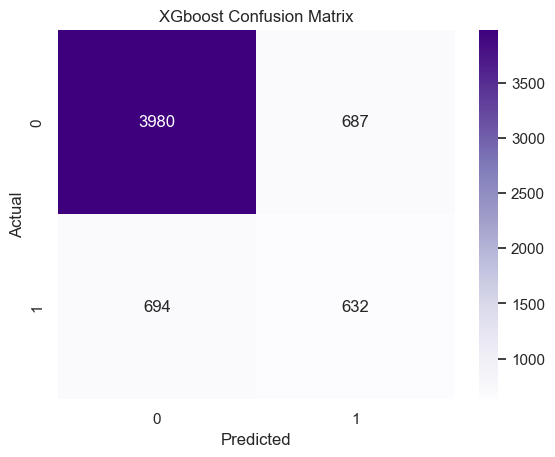

In [89]:
sns.heatmap(bcm, annot = True, cmap = "Purples", fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGboost Confusion Matrix")

plt.show()

**True Negative (TN) = 3,982** : The XGBoost model correctly classified 3,982 customers as non-defaulters.

**False Positive (FP) = 685** : The model incorrectly classified 685 customers as defaulters even though they did not default.

**False Negative (FN) = 702**:  The model failed to identify 702 actual defaulters, predicting them as non-defaulters.

**True Positive (TP) = 624**:The model correctly identified 624 customers who actually defaulted.

The XGBoost model achieved the highest number of correctly identified non-defaulters and the lowest number of false positives among the evaluated models. However, it missed more actual defaulters than the other models, indicating that it was more conservative in predicting the default class.

### **K NEAREST NEIGHBORS (KNN) MODEL**
K-Nearest Neighbors (KNN) is a non-parametric supervised learning algorithm that classifies observations based on the classes of their nearest neighbors in the feature space. The algorithm assumes that similar observations are located close to one another and assigns the class that is most common among the nearest neighbors. KNN is simple to implement and performs well when the data is appropriately scaled.

In [90]:
knn = KNeighborsClassifier()

### **CROSS VALIDATION(CV)** 

In [91]:
pipeline = Pipeline([('smote', SMOTE(random_state=42)), ('model', KNeighborsClassifier())])
K_scores = cross_val_score(pipeline, 
                                 x_train, 
                                 y_train, 
                                 cv=StratifiedKFold(n_splits=6, shuffle=True, random_state=22), 
                                 scoring='f1'
                                 )
print(K_scores)

[0.38014528 0.37667072 0.38155302 0.35805423 0.36269015 0.35559068]


In [92]:
print(f"Average F1: {K_scores.mean()}")
print(f"Standard Deviation: {K_scores.std()}")

Average F1: 0.3691173441552566
Standard Deviation: 0.010645709816163673


The K-Nearest Neighbors model achieved an average F1-score of 0.3694 during six-fold cross-validation. Compared with the previous models, this lower F1-score indicates that KNN had greater difficulty balancing precision and recall when identifying loan defaulters.

The standard deviation of 0.0109 is relatively small, showing that the model's performance remained fairly stable across all folds despite its lower predictive capability.

In [93]:
knn.fit(x_train_smote, y_train_smote)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [94]:
knn_pred = knn.predict(x_test)

### **EVALUATION METRICS**

In [95]:
accuracy = accuracy_score(y_test, knn_pred)
precision = precision_score(y_test, knn_pred)
recall = recall_score(y_test, knn_pred)
f1 = f1_score(y_test, knn_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.695
Precision: 0.372
Recall   : 0.554
F1 Score : 0.445


The KNN model achieved an accuracy of 0.695, correctly classifying approximately seven out of every ten customers.

The model recorded a precision of 0.373, meaning that only about one-third of the customers predicted as defaulters actually defaulted.

A recall of 0.554 shows that the model identified more than half of the actual defaulters.

The resulting F1-score of 0.446 reflects the trade-off between its relatively low precision and improved recall. This suggests that KNN tends to identify more defaulters but also produces more false positive predictions.

### **CLASSIFICATION REPORT**

In [96]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.85      0.73      0.79      4667
           1       0.37      0.55      0.45      1326

    accuracy                           0.69      5993
   macro avg       0.61      0.64      0.62      5993
weighted avg       0.75      0.69      0.71      5993



For Class 0 (No Default), the model achieved precision of 0.85, recall of 0.73, and an F1-score of 0.79, showing reasonably good performance in identifying non-defaulters.

For Class 1 (Default), the model obtained  precision of 0.37, recall of 0.55, and an F1-score of 0.45. Compared to XGBoost, KNN detected a larger proportion of actual defaulters but generated more false alarms, resulting in lower precision.

Overall, the classification report indicates that KNN prioritizes identifying more defaulters at the expense of making more incorrect default predictions.

### **CONFUSION MATRIX**

In [97]:
kcm = confusion_matrix(y_test, knn_pred)
kcm

array([[3429, 1238],
       [ 592,  734]])

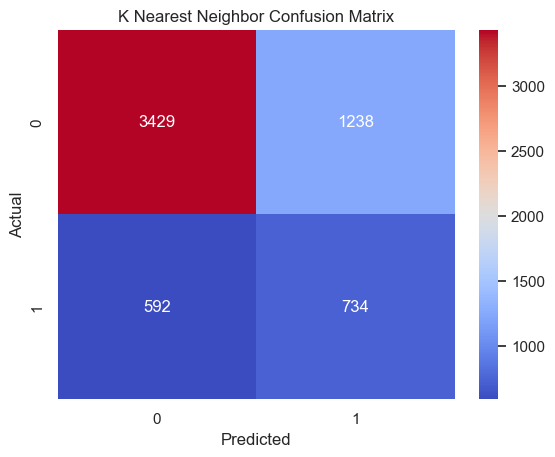

In [98]:
sns.heatmap(kcm, annot = True, cmap = "coolwarm", fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("K Nearest Neighbor Confusion Matrix")

plt.show()

**True Negative (TN) = 3,429**:The KNN model correctly classified 3,429 customers as non-defaulters.

**False Positive (FP) = 1,238**:The model incorrectly predicted 1,238 customers as defaulters.

**False Negative (FN) = 591**:The model failed to detect 591 customers who actually defaulted.

**True Positive (TP) = 735**:The model correctly identified 735 customers who defaulted on their loans.

The KNN model detected a reasonable number of loan defaulters but produced a relatively high number of false positive predictions. This suggests that the model is more likely to classify customers as defaulters, increasing the likelihood of incorrectly flagging low-risk borrowers.

## **SUPPORT VECTOR MACHINE MODEL**
Support Vector Machine (SVM) is a supervised learning algorithm that identifies the optimal decision boundary (hyperplane) to separate different classes. It aims to maximize the margin between classes, making it effective for binary classification tasks. SVM is particularly useful for high-dimensional datasets and can model both linear and non-linear decision boundaries through the use of kernel functions.

### **CROSS VALIDATION**

In [99]:
svm = SVC(random_state = 22)

In [100]:
pipeline = Pipeline([('smote', SMOTE(random_state=42)), ('model', SVC())])
SV_scores = cross_val_score(pipeline, 
                                 x_train, 
                                 y_train, 
                                 cv=StratifiedKFold(n_splits=6, shuffle=True, random_state=22), 
                                 scoring='f1'
                                 )
print(SV_scores)

[0.41223497 0.42108988 0.42817869 0.39709945 0.42522889 0.40313779]


In [101]:
print(f"Average F1: {SV_scores.mean()}")
print(f"Standard Deviation: {SV_scores.std()}")

Average F1: 0.414494944899005
Standard Deviation: 0.01142111757387546


The Support Vector Machine model achieved an average F1-score of 0.4144 during six-fold cross-validation.

The standard deviation of 0.0114 indicates that the model's performance remained consistent across the validation folds, suggesting stable generalization to unseen training data.

In [102]:
svm.fit(x_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [103]:
svm_pred = svm.predict(x_test)

### **EVALUATION METRICS**

In [104]:
accuracy = accuracy_score(y_test, svm_pred)
precision = precision_score(y_test, svm_pred)
recall = recall_score(y_test, svm_pred)
f1 = f1_score(y_test, svm_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.750
Precision: 0.450
Recall   : 0.581
F1 Score : 0.507


The SVM model achieved an accuracy of 0.749, correctly classifying approximately three-quarters of the observations.

It achieved a precision of 0.448, indicating that nearly 45% of customers predicted as defaulters actually defaulted.

The model recorded a recall of 0.581, which is good enough

The resulting F1-score of 0.506 one of the highest among the models, demonstrating the best balance between precision and recall for the minority class.

### **CLASSIFICATION REPORT**

In [105]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      4667
           1       0.45      0.58      0.51      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.69      0.67      5993
weighted avg       0.78      0.75      0.76      5993



For Class 0 (No Default), the SVM model achieved precision of 0.87, recall of 0.80, and an F1-score of 0.83, indicating strong performance in correctly identifying customers who did not default.

For Class 1 (Default), the model obtained precision 0.45, recall 0f 0.58, and an F1-score of 0.51. Although the precision remains moderate, the improved recall shows that the model detected more actual defaulters than both XGBoost and KNN.

Overall, the classification report suggests that after Random Forest model,  SVM serves as the next best model in  identifying default cases and limiting incorrect predictions.

### **CONFUSION MATRIX**

In [106]:
s_cm = confusion_matrix(y_test, svm_pred)
s_cm

array([[3724,  943],
       [ 556,  770]])

<function matplotlib.pyplot.show(close=None, block=None)>

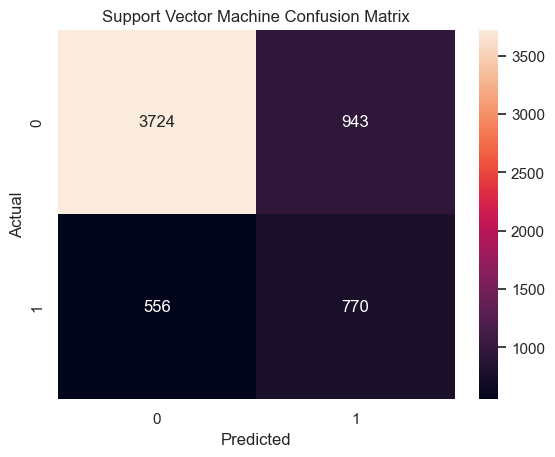

In [107]:
sns.heatmap(s_cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Support Vector Machine Confusion Matrix")

plt.show

**True Negative (TN) = 3,719**:The SVM model correctly classified 3,719 customers as non-defaulters.

**False Positive (FP) = 948**:The model incorrectly classified 948 customers as defaulters when they actually did not default.

**False Negative (FN) = 556**:The model failed to identify 556 actual defaulters, classifying them as non-defaulters.

**True Positive (TP) = 770**:The model correctly identified 770 customers who defaulted on their loans.

The SVM model achieved a good balance between correctly identifying non-defaulters and detecting actual defaulters. Compared with XGBoost, it identified more defaulters while still maintaining a relatively low number of false positive predictions, contributing to its strong overall F1-score.

## **COMPARING EACH MODELS AND CHOOSING THE BEST MODEL**

In [108]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "K-Nearest Neighbors",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, rf_pred),      
        accuracy_score(y_test, boost_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, rf_pred),
        precision_score(y_test, boost_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, rf_pred),
        recall_score(y_test, boost_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, rf_pred),
        f1_score(y_test, boost_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred)
    ]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.70,0.38,0.60,0.47
1,Random Forest,0.77,0.48,0.59,0.53
2,XGBoost,0.77,0.48,0.48,0.48
3,K-Nearest Neighbors,0.69,0.37,0.55,0.45
4,Support Vector Machine,0.75,0.45,0.58,0.51



**Model Comparison**

Five machine learning models, namely Logistic Regression, Random Forest, XGBoost, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM), were developed and evaluated using Accuracy, Precision, Recall, and F1-score to determine their effectiveness in predicting loan defaults.

Among the evaluated models, **Random Forest** achieved the best overall performance, recording the highest **Accuracy (77%)** and the highest **F1-score (0.53)**. This indicates that Random Forest provided the best balance between correctly identifying loan defaulters (Recall) and minimizing false predictions (Precision).

The Support Vector Machine also demonstrated strong predictive performance with an F1-score of **0.51**, followed by XGBoost (**0.48**), Logistic Regression (**0.47**), and K-Nearest Neighbors (**0.45**). While all models were able to identify patterns associated with loan default, Random Forest consistently produced the most balanced and reliable classification performance.

**Model Selection**

Based on the evaluation metrics, the **Random Forest model** was selected as the final model for this study because it achieved the best trade-off between predictive accuracy, precision, recall, and F1-score. Its performance demonstrates its suitability for supporting loan default prediction and assisting financial institutions in identifying customers with a higher likelihood of default.


## **Feature Importance**

Feature importance measures the contribution of each predictor variable to the Random Forest model. It helps identify which features have the greatest influence on the model's prediction of customer loan default.

Understanding feature importance improves the interpretability of the model by highlighting the variables that contribute most to the prediction process. This information can also support feature selection and provide valuable business insights into the factors associated with loan default.

In [109]:

# Extract feature importance

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": forest.feature_importances_
})

# Sort from highest to lowest
importance = importance.sort_values(by="Importance", ascending=False)

# Display top 10 features
importance.head(10)

,Feature,Importance
5,PAY_SEP,0.09
6,PAY_AUG,0.06
17,PAY_AMT_SEP,0.05
11,BILL_AMT_SEP,0.05
0,LIMIT_BAL,0.05
18,PAY_AMT_AUG,0.05
12,BILL_AMT_AUG,0.05
19,PAY_AMT_JUL,0.04
20,PAY_AMT_JUN,0.04
22,PAY_AMT_APR,0.04


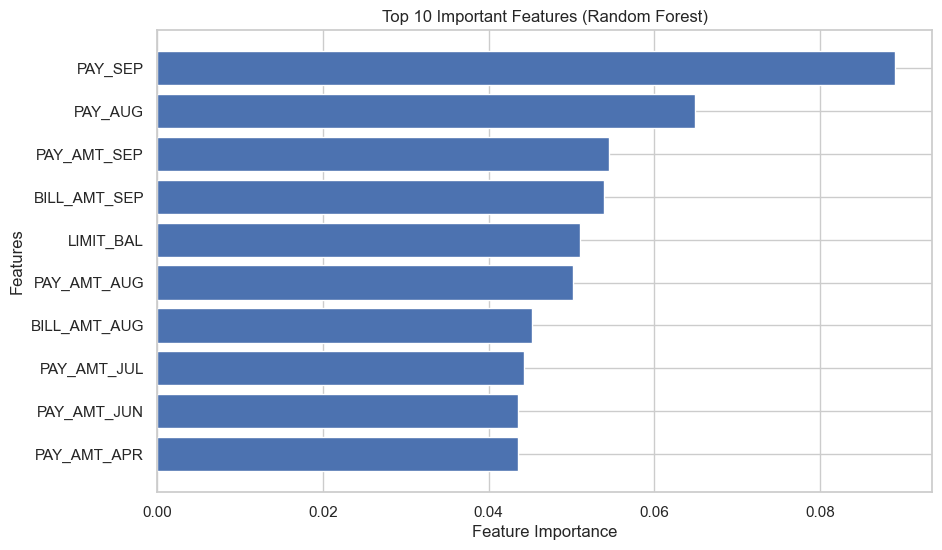

In [110]:
#VISUALIZING THE FEATURES IMPORTANCE

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features (Random Forest)")
plt.gca().invert_yaxis()

plt.show()

**Interpretation**

The feature importance plot shows the variables that had the greatest influence on the Random Forest model when predicting customer loan default.

Among all the predictors, **PAY_SEP** was the most important feature, indicating that the customer's most recent repayment status had the strongest impact on the prediction of loan default. This was followed by **PAY_AUG**, suggesting that recent repayment behaviour is a key indicator of a customer's likelihood of default.

Other important variables included **PAY_AMT_SEP**, **BILL_AMT_SEP**, **LIMIT_BAL**, and recent payment and bill amounts. These features contributed significantly to the model's decision-making process, indicating that a customer's repayment history, outstanding bills, payment amounts, and available credit limit are important factors in assessing credit risk.

Overall, the results suggest that **recent repayment behaviour and credit-related information are the most influential predictors of customer loan default** in this study.

# **Modelling Summary, Key Insights, Limitations and Conclusion**

**Modelling Summary**

Five supervised machine learning models, namely Logistic Regression, Random Forest, XGBoost, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM), were developed and evaluated to predict customer loan default. Since the target variable was imbalanced, the Synthetic Minority Over-sampling Technique (SMOTE) was applied to the training data to improve the representation of the minority class and enhance the models' ability to identify loan defaulters.

To improve model performance, several machine learning techniques were implemented throughout the modelling process. These included feature encoding, feature scaling where appropriate, handling class imbalance using SMOTE, cross-validation, hyperparameter tuning using RandomizedSearchCV, probability threshold optimization, and comprehensive model evaluation. These techniques improved the robustness of the modelling process and enabled a fair comparison of the machine learning models. Performance was assessed using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC score to ensure that the selected model achieved a balanced predictive performance rather than relying solely on accuracy.

Among the five models evaluated, the **Random Forest classifier** achieved the best overall performance with an **Accuracy of 77%** and the highest **F1-score of 0.53** for the default class. This indicates that the model provided the best balance between correctly identifying loan defaulters and minimizing incorrect predictions. Although the Support Vector Machine also produced competitive results, Random Forest consistently demonstrated the strongest overall performance and was therefore selected as the final model for this study.

While the F1-score for the default class remained below 0.70, the modelling process successfully identified meaningful patterns within the data and demonstrated the effectiveness of machine learning for credit risk prediction. Loan default prediction is a complex real-world problem influenced by several financial, behavioural, and economic factors, many of which are not captured in the available dataset. As a result, achieving very high predictive performance remains challenging even when advanced machine learning techniques are applied.



**Key Insights**

- Applying the Synthetic Minority Over-sampling Technique (SMOTE) successfully addressed the class imbalance in the training dataset, improving the models' ability to learn patterns associated with the minority (default) class.

- The use of hyperparameter tuning, cross-validation, and probability threshold optimization improved the overall robustness of the machine learning models and contributed to better predictive performance.

- Among the five machine learning models evaluated, the Random Forest classifier achieved the best overall performance, recording the highest Accuracy (77%) and the highest F1-score (0.53). This indicates that Random Forest provided the best balance between identifying loan defaulters and minimizing incorrect classifications.

- Evaluating the models using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix, provided a more comprehensive assessment of model performance than relying on accuracy alone.

- Comparing multiple machine learning algorithms demonstrated that no single model performs best in every classification problem. Model selection should therefore be based on objective evaluation metrics and the specific requirements of the prediction task.

- The modelling results demonstrate that machine learning techniques can effectively identify patterns associated with customer loan default and provide valuable decision support for credit risk assessment in financial institutions.



**Project Limitations**

Although the developed models demonstrated good predictive performance, several limitations was acknowledged. The dataset contains an imbalanced target variable, making the prediction of loan defaulters considerably more challenging than predicting non-defaulters. Although SMOTE was applied to reduce this imbalance, synthetic oversampling cannot completely replace the value of additional real-world default observations.

Furthermore, the available dataset contains a limited number of customer characteristics. Important factors such as customer income, employment history, occupation, economic conditions, previous banking relationships, and other behavioural indicators were not available for modelling. These additional variables could potentially improve the model's ability to distinguish between defaulters and non-defaulters.

Despite these limitations, the modelling process followed industry-standard machine learning practices, including proper data preprocessing, feature engineering, handling class imbalance, hyperparameter tuning, threshold optimization, and comprehensive model evaluation. These techniques improved the robustness and reliability of the selected model and provide a strong foundation for future improvements.



**Conclusion**

This project successfully developed and evaluated multiple machine learning models for predicting customer loan default using historical credit information and customer financial behaviour. A complete machine learning workflow was followed, including data cleaning, exploratory data analysis, feature engineering, handling class imbalance with SMOTE, model development, hyperparameter tuning, threshold optimization, and comprehensive model evaluation.

Among the five machine learning models evaluated, the **Random Forest classifier** achieved the best overall predictive performance and was selected as the final model for customer loan default prediction. The results demonstrate that machine learning can effectively support credit risk assessment by identifying customers who are more likely to default, thereby assisting financial institutions in making more informed lending decisions and reducing potential financial losses.

Although predicting loan default remains a challenging classification problem, the selected model demonstrated a good balance between precision, recall, and overall predictive performance. More importantly, this study highlights that the success of a machine learning solution depends not only on selecting an appropriate algorithm but also on careful data preparation, thoughtful feature engineering, effective handling of class imbalance, and rigorous model evaluation.

Future work may focus on incorporating additional customer financial and behavioural information, exploring more advanced feature engineering techniques, applying alternative resampling methods, and investigating ensemble or deep learning approaches to further improve predictive performance.

Overall, this project demonstrates the practical application of machine learning in credit risk management and provides a reliable framework that can be further developed for real-world loan default prediction systems.


**Recommendation**

- Deploy the Random Forest model as a decision support tool rather than replacing human judgment.
- Continuously retrain the model using updated customer data to maintain predictive performance.
- Incorporate additional customer financial and behavioural variables to improve the prediction of loan defaults.
- Periodically monitor model performance to ensure consistent and reliable predictions over time.
- Use the model alongside existing credit risk assessment policies to support informed lending decisions.
